# Лабораторна робота №1. Очищення, нормалізація та валідація агрономічних даних (R)

**Спеціальність / Дисципліна:** Аналіз та візуалізація даних для бізнесу, освіти та науки  
**Варіант:** 014 — Сільське господарство (поля, урожайність, супутникові індекси)  
**Мова реалізації:** R (перевірено на 4.6.1)  
**Середовище:** Jupyter Notebook (IRkernel)

---

## 0. Мета та модель даних

Робота відтворює Варіант 014 за оригінальним завданням: генеруємо синтетичні агрономічні дані, діагностуємо їхні проблеми, очищуємо та обчислюємо десять показників. Один рядок відповідає одному супутниковому спостереженню поля в сезоні 2024 і має дату `obs_date`. Господарство, культура, сорт, площа, ґрунт, дати агрооперацій, урожайність, добрива та зрошення належать фізичному полю й повторюються між його спостереженнями; NDVI змінюється в часі. Помилки вносимо на рівні окремих рядків, тому перед польовими KPI відновлюємо представницькі атрибути за доступними коректними значеннями.

Оригінальні матеріали: `Завдання до лабораторної роботи №1.md` та загальні методичні вказівки в корені проєкту. Пріоритет мають вимоги Варіанту 014. Дані синтетичні, а їхні агрономічні відмінності є описовими й не доводять причинного впливу.

### 0.1 Повний глосарій термінів, агрономічних показників та метрик

Для забезпечення максимальної прозорості та зручності сприйняття аналітичних матеріалів нижче наведено вичерпний довідник термінів, одиниць виміру, статистичних метрик та агрономічних показників, використаних у цій лабораторній роботі:

#### 1. Агрономічні змінні та атрибути полів
- **`field_id` / `base_field`** — унікальний ідентифікатор фізичного поля (наприклад, `F0001`–`F0180`). Поле `base_field` використовується після об'єднання близьких дублікатів та очищення від технологічних суфіксів.
- **`farm_id`** — ідентифікатор сільськогосподарського підприємства / агрохолдингу (`FARM01`–`FARM12`).
- **`crop` (Сільськогосподарська культура)** — вирощувана культура: `Wheat` (пшениця), `Corn` (кукурудза), `Soy` (соя), `Sunflower` (соняшник).
- **`variety` (Сорт / Гібрид)** — конкретна селекційна форма культури (`Corn-V1`...`Corn-V5`).
- **`soil_type` (Тип ґрунту)** — класифікація ґрунтового покриву: `Chernozem` (чорнозем), `Loam` (суглинок), `Sandy` (піщаний ґрунт), `Clay` (глинистий ґрунт).
- **`fertilizer_n_kg_ha`** — норма внесення азотних добрив у кілограмах діючої речовини азоту на гектар (кг N/га).
- **`irrigation`** — обсяг штучного зрошення в міліметрах водного стовпа (мм).
- **`rainfall_season`** — сумарна кількість природних сезонних опадів на полі (мм).
- **`grain_moisture_pct`** — вологість зерна під час збирання у відсотках (%).
- **`contractor`** — назва сервісної компанії / підрядника, що виконував обробіток поля або супутникову зйомку.

#### 2. Супутникові індекси та дистанційне зондування (Remote Sensing)
- **`NDVI (Normalized Difference Vegetation Index)`** — нормалізований вегетаційний індекс. Розраховується за формулою $\text{NDVI} = \frac{\text{NIR} - \text{RED}}{\text{NIR} + \text{RED}}$ і відображає рівень зеленої біомаси та фотосинтетичної активності рослин. Фізичний діапазон нормальної вегетації становить від `0.0` до `1.0` (значення $<0$ вказують на хмари/воду, `~0.1` — відкритий ґрунт, `>0.5` — активну вегетацію).
- **`ndvi_mean` / `ndvi_max`** — середнє та максимальне значення вегетаційного індексу NDVI по пікселях поля на конкретну дату знімка `obs_date`.
- **`Cloud Gap (Хмарна прогалина)`** — період суцільної хмарності (15–21 червня), коли оптичні супутники не можуть зробити якісні знімки поверхні, що утворює блокові пропуски значень NDVI.
- **`Часова інтерполяція NDVI`** — математичне відновлення пропущених супутникових спостережень за допомогою лінійної інтерполяції між найближчими суміжними датами (для коротких прогалин тривалістю $\le 3$ днів).

#### 3. Одиниці вимірювання та їх конвертація
- **`t_ha` (Тонни на гектар, т/га)** — стандартна метрична одиниця вимірювання урожайності в Україні та Європі ($1 \text{ т/га} = 10 \text{ ц/га}$).
- **`bu_ac` (Бушелі на акр)** — американська одиниця урожайності. Маса одного бушеля залежить від насипної щільності культури, тому коефіцієнти перерахунку у т/га є специфічними:
  - Пшениця / Соя: $1 \text{ bu/ac} \approx 0.0673 \text{ т/га}$ ($60 \text{ lbs/bu}$).
  - Кукурудза: $1 \text{ bu/ac} \approx 0.0628 \text{ т/га}$ ($56 \text{ lbs/bu}$).
  - Соняшник: $1 \text{ bu/ac} \approx 0.0570 \text{ т/га}$ ($38 \text{ lbs/bu}$).
- **`ha` / `ac` (Гектари / Акри)** — одиниці вимірювання площі ($1 \text{ га} \approx 2.47105 \text{ акрів}$, $1 \text{ акр} \approx 0.404686 \text{ га}$).
- **`mm` / `in` (Міліметри / Дюйми)** — одиниці опадів та зрошення ($1 \text{ дюйм} = 25.4 \text{ мм}$).

#### 4. Методи очищення та валідації даних
- **`Outlier (Викид / Аномалія)`** — значення, що виходить за межі фізично та біологічно можливого інтервалу (наприклад, урожайність $< 0.5$ або $> 18$ т/га, NDVI поза $[0, 1]$, від'ємне зрошення чи площа).
- **`yield_outlier`** — прапорець (0 або 1), який позначає аномальні спостереження урожайності.
- **`Near-Duplicates (Близькі дублікати)`** — повторні записи того самого поля з близькими координатами ($\Delta \text{coord} < 0.001^\circ$) та площею ($\Delta \text{area} < 2\%$).
- **`Coord Swap / Date Swap`** — технічні помилки введення: переплутані місцями широта й довгота (`lat`/`lon`) або дата посіву вказана пізніше за дату збирання (`planting_date` > `harvest_date`).
- **`NBSP (Non-breaking space / \u00A0)`** — спецсимвол нерозривного пробілу у текстових полях, який заважає форматуванню та групуванню.

#### 5. Статистичні метрики та KPI
- **`Median (Медіана, p50)`** — робастне (стійке до викидів) значення, що ділить вибірку навпіл.
- **`Mean (Середнє арифметичне)`** — сума значень, поділена на їх кількість (чутливе до крайніх викидів).
- **`IQR (Interquartile Range)`** — міжквартильний розмах ($Q_3 - Q_1$), міра варіативності без урахування викидів.
- **`p90 (90-й процентиль)`** — поріг, нижче якого перебуває 90% спостережень (відображає потенціал високоврожайних полів).
- **`Кореляція Пірсона ($r$)`** — показник лінійного зв'язку між двома змінними від -1.0 до +1.0.
- **`MAR (Missing At Random)`** — випадкові пропуски, зумовлені іншими відомими факторами (наприклад, недоступність даних через дощі під час збирання).
- **`MCAR (Missing Completely At Random)`** — повністю випадкові пропуски, незалежні від інших змінних.
- **`KPI 1–10`** — десять ключових підсумкових аналітичних показників лабораторної роботи (кількість полів, медіани урожайності по культурах і ґрунтах, частка зрошуваних земель, кореляції добрива/урожайність та NDVI/урожайність, втрати від хмарності тощо).

## 1. Генерація даних із контрольованими помилками

### 1.1 Середовище та відтворюваність

Встановлюємо seed 14014 один раз перед генерацією та завантажуємо потрібні пакети. Виводимо R.version.string без обмеження конкретною версією R, а відносні шляхи визначаємо відповідно до розташування проєкту.

In [55]:
set.seed(14014)
suppressPackageStartupMessages({
  library(dplyr)
  library(readr)
  library(stringr)
  library(lubridate)
  library(ggplot2)
  library(tidyr)
})
project_root <- if (dir.exists("../data")) ".." else if (dir.exists("data")) "." else "lab01"
raw_path <- file.path(project_root, "data/raw/generated_dirty.csv")
clean_path <- file.path(project_root, "data/clean/dataset_clean.csv")
log_path <- file.path(project_root, "change_log.csv")
dir.create(dirname(raw_path), recursive = TRUE, showWarnings = FALSE)
dir.create(dirname(clean_path), recursive = TRUE, showWarnings = FALSE)
fig_dir <- file.path(project_root, "figures")
dir.create(fig_dir, recursive = TRUE, showWarnings = FALSE)
options(
  repr.plot.width = 9,
  repr.plot.height = 5,
  tibble.width = Inf,
  pillar.sigfig = 6,
  crayon.enabled = FALSE,
  cli.num_colors = 0
)
cat(R.version.string, "\nSeed: 14014\nПакети: dplyr, readr, stringr, lubridate, ggplot2, tidyr\n")

R version 4.6.1 (2026-06-24 ucrt) 
Seed: 14014
Пакети: dplyr, readr, stringr, lubridate, ggplot2, tidyr


Тестовий запуск показав R 4.6.1 і seed 14014; інші сумісні версії не блокуються; пакети завантажено без повідомлень, що заважають читанню. Відносні шляхи спрямовують результати у data/raw, data/clean та журнал поточної папки роботи.

### 1.2 Майстер-таблиця фізичних полів

Створюємо 180 полів із незмінними сезонними атрибутами у 12 господарствах. Географічна область моделі лежить усередині центральної України; інші регіони цією синтетичною вибіркою не представлені.

In [56]:
n_farms  <- 12
n_fields <- 180
# Область моделі всередині центральної України; не рамка всієї країни.
UA_LAT <- c(48.5, 50.0)
UA_LON <- c(28.5, 34.0)

farm_ids  <- paste0("FARM", str_pad(1:n_farms,  2, pad = "0"))
field_ids <- paste0("F",    str_pad(1:n_fields, 4, pad = "0"))

field_farm <- data.frame(field_id = field_ids,
                           farm_id  = sample(farm_ids, n_fields, replace = TRUE))
field_coords <- data.frame(field_id = field_ids,
                           lat0 = runif(n_fields, UA_LAT[1]+.001, UA_LAT[2]-.001),
                           lon0 = runif(n_fields, UA_LON[1]+.001, UA_LON[2]-.001))

crop_levels <- c("Wheat", "Corn", "Soy", "Sunflower")
soil_levels <- c("Chernozem", "Loam", "Sandy", "Clay")
contractors_base <- c("AgroService Ltd", "Pole Plus", "UkrAgroTech",
                      "Field Master", "GreenCrop", "SunField Co")

field_season <- data.frame(field_id = field_ids) |>
  left_join(field_farm, by = "field_id") |>
  left_join(field_coords, by = "field_id") |>
  mutate(
    season = 2024L,
    crop = sample(crop_levels, n_fields, replace = TRUE, prob = c(.35,.30,.20,.15)),
    soil_type = sample(soil_levels, n_fields, replace = TRUE, prob = c(.40,.30,.15,.15)),
    area_ha = runif(n_fields, 5, 120),
    contractor = sample(contractors_base, n_fields, replace = TRUE),
    variety = paste0(crop, "-V", sample(1:5, n_fields, replace = TRUE)),
    planting_date = as.Date("2024-03-10") + sample(0:71, n_fields, replace = TRUE),
    harvest_date  = as.Date("2024-07-25") + sample(0:82, n_fields, replace = TRUE),
    yield_value = mapply(function(cr) switch(cr,
      Wheat = runif(1, 3, 8), Corn = runif(1, 5, 12),
      Soy = runif(1, 1.5, 4), Sunflower = runif(1, 1.8, 4.5)), crop),
    yield_unit = "t_ha",
    grain_moisture_pct = runif(n_fields, 8, 35),
    fertilizer_n_kg_ha = runif(n_fields, 0, 220),
    pesticide_apps = sample(0:6, n_fields, replace = TRUE),
    irrigation = ifelse(runif(n_fields) < 0.40, 0, runif(n_fields, 50, 400)),
    irrigation_unit = "mm",
    rainfall_season = runif(n_fields, 150, 700),
    rainfall_unit = "mm",
    temp_avg_c  = runif(n_fields, 12, 23),
    note = sample(c("перевірити", "норма", "посуха", "добре",
                    "проблема з дренажем", "зрошення застосовано", "без примітки"),
                  n_fields, replace = TRUE)
  )
cat("Master table:", nrow(field_season), "полів,", ncol(field_season), "колонок\n")

Master table: 180 полів, 23 колонок


Майстер-таблиця містить 180 фізичних полів і 23 атрибути. Ці атрибути належать полю в сезоні 2024 й повторюються для різних дат знімків. Господарства вибираються з 12 ідентифікаторів, а культури — з чотирьох канонічних назв. Така модель дозволяє окремо аналізувати супутникові спостереження та польову урожайність.

### 1.3 Повторні супутникові спостереження

Для кожного поля генеруємо 7–9 дат знімків протягом вегетаційного періоду. Для полів із хмарною прогалиною гарантуємо спостереження в тижні 15–21 червня; окремі короткі пропуски супутникових спостережень потрібні для демонстрації допустимої інтерполяції.

In [57]:
obs_per_field <- sample(7:9, n_fields, replace = TRUE)

obs_rows <- lapply(seq_len(n_fields), function(i) {
  data.frame(field_id = field_ids[i],
             obs_date = sort(as.Date("2024-05-01") +
                             sample(0:152, obs_per_field[i], replace = FALSE)))
})
obs_df <- bind_rows(obs_rows)
obs_df$ndvi_mean <- runif(nrow(obs_df), 0.35, 0.85)
obs_df$ndvi_max <- pmin(pmax(0.5, obs_df$ndvi_mean + runif(nrow(obs_df), 0.05, 0.15)), 0.95)

# ── Cloud gap fields та короткі прогалини визначаємо ДО join ─────────────────
cloud_start <- as.Date("2024-06-15")
cloud_end   <- as.Date("2024-06-21")
n_cloud_fields <- round(0.15 * n_fields)
cloud_gap_fields <- sample(field_ids, n_cloud_fields)

# Гарантуємо знімок у cloud week для кожного cloud-gap поля
for (fld in cloud_gap_fields) {
  fld_obs <- obs_df$obs_date[obs_df$field_id == fld]
  if (!any(fld_obs >= cloud_start & fld_obs <= cloud_end)) {
    obs_df <- bind_rows(obs_df,
      data.frame(field_id = fld,
                 obs_date = cloud_start + sample(0:6, 1),
                 ndvi_mean = runif(1, 0.35, 0.85),
                 ndvi_max = 0.95))
  }
}

# Короткі прогалини (gap ≤3 дні) для демонстрації інтерполяції
impute_demo_fields <- sample(setdiff(field_ids, cloud_gap_fields), 8)
for (fld in impute_demo_fields) {
  fld_obs <- sort(obs_df$obs_date[obs_df$field_id == fld])
  diffs <- diff(as.integer(fld_obs))
  good  <- which(diffs == 3)
  if (length(good) > 0) {
    mid_date <- fld_obs[good[1]] + 1L
    obs_df <- bind_rows(obs_df,
      data.frame(field_id = fld, obs_date = mid_date,
                 ndvi_mean = NA_real_, ndvi_max = NA_real_))
  }
}

df_full <- obs_df |>
  left_join(field_season, by = "field_id") |>
  arrange(field_id, obs_date)

n <- nrow(df_full)
cat("Observation rows:", n, "\nUnique fields:", n_distinct(df_full$field_id),
    "\nObs per field: min =", min(obs_per_field), ", max =", max(obs_per_field), "\n")

Observation rows: 1443 
Unique fields: 180 
Obs per field: min = 7 , max = 9 


Отримано 1 443 базові спостереження для 180 фізичних полів. Значення min=7 та max=9 описують початкову випадкову кількість дат на поле; додані знімки хмарного тижня й демонстраційні прогалини можуть збільшувати її. Повторні рядки одного поля є часовими спостереженнями, а не незалежними полями. Тому середню урожайність у KPI надалі розраховуємо після польової агрегації.

### 1.4 Пропуски NDVI

Протягом 15–21 червня приховуємо NDVI для 15% фізичних полів. Додаткові пропуски супутникових спостережень моделюють розсіяну хмарність поза цим тижнем; їх вносимо до загального рівня близько 15%; довга хмарна прогалина не підлягатиме відновленню.

In [58]:
# Cloud gap: NA для полів у хмарний тиждень
in_cloud <- df_full$field_id %in% cloud_gap_fields &
            df_full$obs_date >= cloud_start & df_full$obs_date <= cloud_end
df_full$ndvi_mean[in_cloud] <- NA_real_
df_full$ndvi_max[in_cloud]  <- NA_real_

# Розсіяна хмарність ПОЗА суцільним хмарним тижнем
not_na_not_cloud <- which(!is.na(df_full$ndvi_mean) &
                          !(df_full$obs_date >= cloud_start & df_full$obs_date <= cloud_end))
n_extra_na <- max(0L, round(0.15 * n) - sum(is.na(df_full$ndvi_mean)))
if (n_extra_na > length(not_na_not_cloud)) {
  n_extra_na <- length(not_na_not_cloud) - 10
}
extra_na_idx <- sample(not_na_not_cloud, n_extra_na)
df_full$ndvi_mean[extra_na_idx] <- NA_real_
df_full$ndvi_max[extra_na_idx]  <- NA_real_

total_ndvi_na <- sum(is.na(df_full$ndvi_mean))
cat("Cloud gap NA:", sum(in_cloud), "рядків\n")
cat("Розсіяна хмарність / додаткові NA:", n_extra_na, "рядків\n")
cat("Загалом NDVI NA:", total_ndvi_na, "(", round(total_ndvi_na/n*100,1), "%)\n")
cat("Cloud gap полів:", n_cloud_fields, "з", n_fields,
    "(", round(n_cloud_fields/n_fields*100,1), "%)\n")

Cloud gap NA: 28 рядків
Розсіяна хмарність / додаткові NA: 187 рядків
Загалом NDVI NA: 216 ( 15 %)
Cloud gap полів: 27 з 180 ( 15 %)


Хмарна прогалина охоплює 27 із 180 полів, тобто 15%, і 28 наявних знімків у тижні 15–21 червня. Додано 187 випадкових NA, що моделюють розсіяну хмарність, поза цим тижнем; разом із однією демонстраційною короткою прогалиною це дає 216 відсутніх NDVI, або близько 15% базових спостережень. Повна відсутність стосується наявних знімків поля в тижні, а не щоденного моніторингу, якого ця модель не містить. Хмарні NA залишаться пропусками; коротку прогалину можна відновити лише за достатньо близьких сусідніх дат.

### 1.5 Пропуски урожайності та одиниць

Створюємо синтетичний календар погоди: шість тижнів із 15 мм опадів і сім дощових тижнів із 55 мм. Дощовим вважаємо тиждень із понад 40 мм; збирання в такі тижні збільшує вагу відбору поля для пропуску урожайності утричі. Це механізм MAR: відсутність залежить від відомих дати збирання й погоди, а не від самого значення урожайності. Календар є навчальною моделлю регіональних умов, а не фактичними метеоспостереженнями 2024 року; сезонні опади полів генеруються окремо. Одиниці та ґрунти додатково приховуємо випадково. Для перевірки MAR порівнюємо частку полів із відсутньою урожайністю в дощові та інші тижні збирання; кожне фізичне поле враховується один раз.

In [59]:
# MAR залежить від збирання у дощові тижні синтетичного календаря.
weather_weeks <- data.frame(
  week_start = seq(as.Date("2024-07-21"), as.Date("2024-10-13"), by = "7 days")
)
weather_weeks$week_end <- weather_weeks$week_start + 6L
weather_weeks$rain_mm <- ifelse(weather_weeks$week_start >= as.Date("2024-09-01"), 55, 15)
weather_weeks$rainy <- weather_weeks$rain_mm > 40

harvest_week <- findInterval(as.numeric(field_season$harvest_date), as.numeric(weather_weeks$week_start))
weights <- ifelse(weather_weeks$rainy[harvest_week], 3, 1)

print(weather_weeks, row.names = FALSE)

ymiss_flds <- sample(field_ids, round(0.11 * n_fields), prob = weights)
df_full$yield_value[df_full$field_id %in% ymiss_flds] <- NA_real_
set_na <- function(col, pct) {
  idx <- sample(seq_len(n), round(pct*n))
  df_full[[col]][idx] <<- NA
  invisible(idx)
}
set_na("soil_type", 0.085)
set_na("yield_unit", 0.085)
set_na("irrigation_unit", 0.075)
set_na("rainfall_unit", 0.075)
cat("yield_value NA:", sum(is.na(df_full$yield_value)), "рядків;",
    round(mean(is.na(df_full$yield_value))*100,1), "%\n")

# MAR: один голос на фізичне поле, без повторів супутникових знімків.
mar_fields <- field_season |>
  transmute(field_id, rainy_week=weather_weeks$rainy[harvest_week]) |>
  left_join(df_full |> group_by(field_id) |>
    summarise(yield_missing=all(is.na(yield_value)), .groups="drop"), by="field_id")
mar_check <- mar_fields |>
  mutate(harvest_week_type=if_else(rainy_week, "Дощовий", "Інший")) |>
  group_by(harvest_week_type) |>
  summarise(fields=n(), yield_NA_fields=sum(yield_missing),
            yield_NA_pct=round(100*mean(yield_missing),2), .groups="drop")
cat("MAR — урожайність NA за тижнем збирання (% полів):\n")
print(mar_check)

 week_start   week_end rain_mm rainy
 2024-07-21 2024-07-27      15 FALSE
 2024-07-28 2024-08-03      15 FALSE
 2024-08-04 2024-08-10      15 FALSE
 2024-08-11 2024-08-17      15 FALSE
 2024-08-18 2024-08-24      15 FALSE
 2024-08-25 2024-08-31      15 FALSE
 2024-09-01 2024-09-07      55  TRUE
 2024-09-08 2024-09-14      55  TRUE
 2024-09-15 2024-09-21      55  TRUE
 2024-09-22 2024-09-28      55  TRUE
 2024-09-29 2024-10-05      55  TRUE
 2024-10-06 2024-10-12      55  TRUE
 2024-10-13 2024-10-19      55  TRUE
yield_value NA: 155 рядків; 10.7 %
MAR — урожайність NA за тижнем збирання (% полів):
# A tibble: 2 × 4
  harvest_week_type fields yield_NA_fields yield_NA_pct
  <chr>              <int>           <int>        <dbl>
1 Інший                 90               4         4.44
2 Дощовий               90              16        17.78


Таблиця погоди охоплює 13 тижнів від 21 липня до 19 жовтня: шість мають 15 мм, сім — 55 мм опадів. Межа 40 мм визначає дощові тижні, для яких вага відбору поля дорівнює 3 проти 1 в інших тижнях; це ваги вибірки, а не індивідуальні ймовірності 300%. Польова перевірка показала 16/90 = 17.78% пропусків урожайності в дощові тижні проти 4/90 = 4.44% в інші тижні. Ця різниця узгоджується зі сконструйованим MAR-механізмом, але сама по собі не доводить MAR у реальних даних. Урожайність відсутня у 155 базових рядках, або 10.7%. Пропуски створено на рівні фізичного поля, тому вони повторюються в усіх його знімках і не усуваються звичайною польовою агрегацією. Пропуски одиниць і ґрунтів внесено на рівні рядків; у фінальному CSV їхні частки трохи змінюються через додавання дублікатів.

### 1.6 Контрольовані аномалії

Вносимо нульову або від’ємну та надто високу урожайність у початкових т/га. Додаємо порушення діапазонів NDVI, вологості й температури та негативні площі й водні показники; після змішування одиниць діагностика повинна правильно розпізнати ці помилки.

In [60]:
# yield < 0
n_yneg <- round(0.007 * n)
idx_yneg <- sample(which(!is.na(df_full$yield_value)), n_yneg)
df_full$yield_value[idx_yneg] <- runif(n_yneg, -0.5, 0)
# yield > 18
n_yhi <- round(0.008 * n)
idx_yhi <- sample(setdiff(which(!is.na(df_full$yield_value)), idx_yneg), n_yhi)
df_full$yield_value[idx_yhi] <- runif(n_yhi, 19, 35)
# moisture поза [8,35]
n_mo <- round(0.01 * n)
idx_mo <- sample(n, n_mo)
df_full$grain_moisture_pct[idx_mo] <- ifelse(runif(n_mo)<.5, runif(n_mo,.5,4), runif(n_mo,46,60))
# temp поза [5,40]
n_te <- round(0.005 * n)
idx_te <- sample(n, n_te)
df_full$temp_avg_c[idx_te] <- ifelse(runif(n_te)<.5, runif(n_te,-5,4), runif(n_te,41,50))
# NDVI поза [0,1]
n_no <- round(0.008 * n)
idx_no <- sample(which(!is.na(df_full$ndvi_mean)), min(n_no, sum(!is.na(df_full$ndvi_mean))-5))
df_full$ndvi_mean[idx_no] <- ifelse(runif(length(idx_no))<.5,
  runif(length(idx_no),-.3,-.01), runif(length(idx_no),1.01,1.3))
# ndvi_max < ndvi_mean
n_ns <- round(0.01 * n)
idx_ns <- sample(setdiff(which(!is.na(df_full$ndvi_mean) & !is.na(df_full$ndvi_max)), idx_no), n_ns)
tmp_mx <- df_full$ndvi_max[idx_ns]
df_full$ndvi_max[idx_ns]  <- df_full$ndvi_mean[idx_ns] - runif(n_ns, 0.01, 0.1)
df_full$ndvi_mean[idx_ns] <- tmp_mx
# irrigation/rainfall/area < 0
n_in <- round(0.005 * n)
df_full$irrigation[sample(n, n_in)] <- -runif(n_in, 1, 50)
n_rn <- round(0.005 * n)
df_full$rainfall_season[sample(n, n_rn)] <- -runif(n_rn, 1, 100)
n_an <- round(0.004 * n)
df_full$area_ha[sample(n, n_an)] <- runif(n_an, -5, 0)

cat("yield neg/hi:", n_yneg, "/", n_yhi, "  NDVI bad:", length(idx_no), "/", n_ns, "\n")
cat("moisture:", n_mo, " temp:", n_te, " irr<0:", n_in, " rain<0:", n_rn, " area≤0:", n_an, "\n")

yield neg/hi: 10 / 12   NDVI bad: 12 / 14 
moisture: 14  temp: 7  irr<0: 7  rain<0: 7  area≤0: 6 


Створено 10 непозитивних і 12 завищених значень урожайності, 12 виходів NDVI за діапазон та 14 спеціально заданих порушень max≥mean. По 14 і 7 рядків відповідно мають аномальну вологість і температуру; по 7 рядків — негативне зрошення та опади, 6 — непозитивну площу. Після змішування одиниць кількісний контроль урожайності потребує зворотної конверсії в т/га. Вихід NDVI за діапазон сам також може створити max<mean, тому фактична кількість таких порушень перевіряється окремо.

### 1.7 Помилки категорій та тексту

Змінюємо написання назв культур і ґрунтів, використовуючи відомі синоніми. Для підрядників змінюємо лише регістр і пробіли, зберігаючи самого підрядника; у примітки додаємо невидимі пробіли.

In [61]:
# crop aliases
crop_aliases <- list(Wheat=c("wheat","WHEAT "), Corn=c("Corn","Maize"),
                     Soy=c("Soy","soya"), Sunflower=c("Sunflower","Sun-flower"))
n_cd <- round(0.25 * n)
idx_cd <- sample(n, n_cd)
df_full$crop_chr <- df_full$crop
for (i in idx_cd) {
  df_full$crop_chr[i] <- sample(crop_aliases[[df_full$crop[i]]], 1)
}
# soil aliases
soil_aliases <- list(Chernozem=c("Chernozem","chernozem"), Loam=c("Loam","loamy"),
                     Sandy=c("Sandy"), Clay=c("Clay","CLAY "))
n_sd <- round(0.20*n)
idx_sd <- sample(which(!is.na(df_full$soil_type)), min(n_sd,sum(!is.na(df_full$soil_type))))
df_full$soil_chr <- df_full$soil_type
for (i in idx_sd) {
  orig <- df_full$soil_type[i]
  if (!is.null(soil_aliases[[orig]])) {
    df_full$soil_chr[i] <- sample(soil_aliases[[orig]], 1)
  }
}
# contractor dirty
contr_dirty <- c("agroservice ltd","POLE PLUS","  UkrAgroTech ","field master",
                 "GreenCrop ","sunfield co")
n_cdr <- round(0.35 * n)
idx_cdr <- sample(n, n_cdr)
df_full$contractor[idx_cdr] <- contr_dirty[match(df_full$contractor[idx_cdr], contractors_base)]
# note NBSP
note_nz <- which(df_full$note != "без примітки")
idx_nbsp <- sample(note_nz, round(0.05*length(note_nz)))
df_full$note[idx_nbsp] <- paste0(df_full$note[idx_nbsp], "\u00A0")

cat("crop:", n_cd, " soil:", length(idx_sd), " contractor:", n_cdr, " note NBSP:", length(idx_nbsp), "\n")

crop: 361  soil: 289  contractor: 505  note NBSP: 62 


Для внесення категоріального шуму вибрано 361 запис культури, 289 записів ґрунту й 505 записів підрядника; у 62 примітки додано нерозривний пробіл. Ці числа означають вибрані для генерації рядки, а не остаточну кількість відмінних написань: серед варіантів є й канонічні назви. Підрядник залишається тією самою особою чи організацією, змінюється лише його запис. Частотні таблиці покажуть фактично отримані категорії.

### 1.8 Змішані одиниці

Частину площ виражаємо в акрах, зрошення та опадів — у дюймах, урожайності — у бушелях на акр. Для перерахунку використовуємо 0.404685642 га/акр, 25.4 мм/дюйм і коефіцієнти за культурою: Wheat 0.0673, Corn 0.0628, Soy 0.0673, Sunflower 0.0570 т/га на один bu/ac. Відсутню одиницю не можна відновити тільки за величиною числа.

In [62]:
AC_TO_HA <- 0.404685642
IN_TO_MM <- 25.4

df_full$area_unit <- "ha"
# area_unit NA: ~7.5% ПЕРЕД mixed units
n_au_na <- round(0.075 * n)
idx_au_na <- sample(n, n_au_na)
df_full$area_unit[idx_au_na] <- NA_character_

# Area ac: ~30% серед рядків із відомою одиницею
known_au <- which(!is.na(df_full$area_unit))
n_ac <- round(0.30 * n)
if (n_ac > length(known_au)) {
  n_ac <- length(known_au) - 5
}
idx_ac <- sample(known_au, n_ac)
df_full$area_ha[idx_ac]   <- df_full$area_ha[idx_ac] / AC_TO_HA
df_full$area_unit[idx_ac] <- "ac"

# irrigation in, rainfall in, yield bu_ac
known_iu <- which(!is.na(df_full$irrigation_unit))
n_iin <- round(0.25 * n)
if (n_iin > length(known_iu)) {
  n_iin <- length(known_iu) - 5
}
idx_iin <- sample(known_iu, n_iin)
df_full$irrigation[idx_iin] <- df_full$irrigation[idx_iin]/IN_TO_MM
df_full$irrigation_unit[idx_iin] <- "in"

known_ru <- which(!is.na(df_full$rainfall_unit))
n_rin <- round(0.25 * n)
if (n_rin > length(known_ru)) {
  n_rin <- length(known_ru) - 5
}
idx_rin <- sample(known_ru, n_rin)
df_full$rainfall_season[idx_rin] <- df_full$rainfall_season[idx_rin]/IN_TO_MM
df_full$rainfall_unit[idx_rin] <- "in"

bu_ac_dict <- data.frame(crop=c("Wheat","Corn","Soy","Sunflower"),
                         coeff=c(0.0673,0.0628,0.0673,0.0570))
known_yu <- which(!is.na(df_full$yield_unit))
n_bu  <- round(0.40 * n)
if (n_bu > length(known_yu)) {
  n_bu <- length(known_yu) - 5
}
idx_bu <- sample(known_yu, n_bu)
df_full$yield_unit[idx_bu] <- "bu_ac"
for (i in idx_bu) {
  cr <- df_full$crop[i]
  co <- bu_ac_dict$coeff[bu_ac_dict$crop == cr]
  if (length(co)==1 && !is.na(df_full$yield_value[i]))
    df_full$yield_value[i] <- df_full$yield_value[i] / co
}

print(bu_ac_dict,row.names=FALSE)
cat("area_unit NA:", round(mean(is.na(df_full$area_unit))*100,1), "%\n")
cat("area ac:", sum(df_full$area_unit=="ac",na.rm=T), " yield bu_ac:", sum(df_full$yield_unit=="bu_ac",na.rm=T), "\n")
cat("irr in:", sum(df_full$irrigation_unit=="in",na.rm=T), " rain in:", sum(df_full$rainfall_unit=="in",na.rm=T), "\n")

      crop  coeff
     Wheat 0.0673
      Corn 0.0628
       Soy 0.0673
 Sunflower 0.0570
area_unit NA: 7.5 %
area ac: 433  yield bu_ac: 577 
irr in: 361  rain in: 361 


Таблиця-словник зберігає коефіцієнт переходу одного bu/ac у т/га для кожної культури: Wheat і Soy — 0.0673, Corn — 0.0628, Sunflower — 0.0570. Ця сама таблиця використовується для генерації, діагностики й очищення, тому коефіцієнти не можуть розійтися між етапами. У базових даних 433 площі задано в акрах, 577 одиниць урожайності — у bu/ac, а по 361 водному показнику — у дюймах. Частка пропусків одиниці площі становить 7.5%. Імперські одиниці є коректними одиницями вимірювання; проблема виникає під час спільного аналізу без конверсії. Рядки без одиниць надалі матимуть NA у стандартизованих величинах.

### 1.9 Числа як текст та формати дат

Частину дат записуємо у форматі DD.MM.YYYY замість ISO. У площі й добривах створюємо десяткові коми та пробіли, а до кількості обробок додаємо текст apps; такі значення потребують явного парсингу.

In [63]:
# Дати DD.MM.YYYY
n_df <- round(0.12 * n)
idx_df <- sample(n, n_df)
df_full$planting_date_chr <- format(df_full$planting_date, "%Y-%m-%d")
df_full$harvest_date_chr  <- format(df_full$harvest_date,  "%Y-%m-%d")
df_full$planting_date_chr[idx_df] <- format(df_full$planting_date[idx_df], "%d.%m.%Y")
df_full$harvest_date_chr[idx_df]  <- format(df_full$harvest_date[idx_df],  "%d.%m.%Y")

# Area text ~10%
df_full$area_chr <- as.character(round(df_full$area_ha, 1))
n_at <- round(0.10 * n)
idx_at <- sample(n, n_at)
df_full$area_chr[idx_at] <- sapply(df_full$area_ha[idx_at], function(v)
  paste0(" ", sub("\\.", ",", formatC(v, format="f", digits=1))))

# Fertilizer text ~10%
df_full$fertilizer_chr <- as.character(round(df_full$fertilizer_n_kg_ha, 1))
n_ft <- round(0.10 * n)
idx_ft <- sample(n, n_ft)
df_full$fertilizer_chr[idx_ft] <- sapply(df_full$fertilizer_n_kg_ha[idx_ft], function(v)
  paste0(" ", sub("\\.", ",", formatC(v, format="f", digits=1)), " "))

# Pesticide ~1%
df_full$pesticide_chr <- as.character(df_full$pesticide_apps)
n_pt <- round(0.01 * n)
idx_pt <- sample(n, n_pt)
df_full$pesticide_chr[idx_pt] <- paste0(df_full$pesticide_apps[idx_pt], " apps")

cat("DD.MM.YYYY:", n_df, "(", round(n_df/n*100,1), "%)\n")
cat("Area text:", n_at, "  Fert text:", n_ft, "  Pesticide text:", n_pt, "\n")

DD.MM.YYYY: 173 ( 12 %)
Area text: 144   Fert text: 144   Pesticide text: 14 


До експорту підготовлено 173 рядки з датами DD.MM.YYYY, що становить 12% базових спостережень. Текстовий запис застосовано до 144 площ, 144 доз добрив і 14 кількостей обробок. Це форматні помилки, для яких достатньо парсингу без зміни змісту вимірювання. Додавання дублікатів змінює ці кількості у фінальному raw CSV.

### 1.10 Хронологія та координати

У частині рядків міняємо місцями дати сівби та збирання. Коректні координати генеруємо лише в області [48.5,50.0] × [28.5,34.0] у центральній Україні, із запасом до країв для близьких дублів. Розташування області перевірено за контуром [geoBoundaries UKR ADM0](https://www.geoboundaries.org/api/current/gbOpen/UKR/ADM0/); це географічне обмеження моделі, а не припущення про всю територію країни. Далі переставляємо координати в частині рядків і додаємо дев’ять очевидно закордонних пар.

In [64]:
# harvest < planting swap
n_de <- round(0.0075 * n)
idx_de <- sample(n, n_de)
tmp_p <- df_full$planting_date_chr[idx_de]
df_full$planting_date_chr[idx_de] <- df_full$harvest_date_chr[idx_de]
df_full$harvest_date_chr[idx_de]  <- tmp_p
# coord swap lat↔lon
n_cs <- round(0.017 * n)
idx_cs <- sample(n, n_cs)
tmp_l <- df_full$lat0[idx_cs]
df_full$lat0[idx_cs] <- df_full$lon0[idx_cs]
df_full$lon0[idx_cs] <- tmp_l
# coord поза Україною
n_co <- round(0.006 * n)
idx_co <- sample(setdiff(seq_len(n), idx_cs), n_co)
df_full$lat0[idx_co] <- runif(n_co, 55, 65)
df_full$lon0[idx_co] <- runif(n_co, 15, 20)

cat("date swap:", n_de, " coord swap:", n_cs, " coord out:", n_co, "\n")

date swap: 11  coord swap: 25  coord out: 9 


На етапі генерації переставлено дати в 11 рядках і координати в 25 рядках; 9 рядків мають явно віддалені координати. Дати після перестановки порушують хронологію, хоча окремі значення залишаються правильними датами сезону. Межі заданої області дозволяють розрізнити переставлену пару координат і позамежний запис. Перевірка області достатня для цього генератора, але для довільних реальних точок усієї України потрібен полігон державного кордону.

### 1.11 Повні та близькі дублікати

Створюємо повторні рядки й додаткові ідентифікатори для чотирьох фізичних полів. Псевдоніми отримують малі відхилення координат і площі; суфікс ідентифікатора служить лише способом генерації та не бере участі в пошуку чи виборі запису для збереження.

In [65]:
n_fd <- round(0.02 * n)
dups_full <- df_full[sample(n, n_fd), ]

n_alias <- 4; alias_src <- sample(field_ids, n_alias)
alias_ids <- paste0(alias_src, "-ALT")
dups_near_list <- lapply(seq_len(n_alias), function(k) {
  src_rows <- df_full[df_full$field_id == alias_src[k], ]
  if (nrow(src_rows) == 0) {
  return(NULL)
}
  alt <- src_rows; alt$field_id <- alias_ids[k]
  alt$lat0 <- alt$lat0 + runif(nrow(alt), -0.0003, 0.0003)
  alt$lon0 <- alt$lon0 + runif(nrow(alt), -0.0003, 0.0003)
  alt$area_ha <- alt$area_ha * (1 + runif(nrow(alt), -0.01, 0.01))
  alt$area_chr <- ifelse(grepl(",", src_rows$area_chr),
    paste0(" ", sub("\\.", ",", formatC(alt$area_ha, format="f", digits=1))),
    as.character(round(alt$area_ha, 1)))
  alt
})
dups_near <- bind_rows(Filter(Negate(is.null), dups_near_list))
df_dirty <- bind_rows(df_full, dups_full, dups_near) |> slice(sample(n()))

cat("Повних дублів:", nrow(dups_full), "\nNear-dup рядків:", nrow(dups_near),
    "(", n_alias, "alias-полів)\nФінальний raw:", nrow(df_dirty), "\n")

Повних дублів: 29 
Near-dup рядків: 34 ( 4 alias-полів)
Фінальний raw: 1506 


Додано 29 повних повторів і 34 спостереження чотирьох полів з додатковими ідентифікаторами. Фінальний raw містить 1 506 рядків: 1 443 базові спостереження плюс ці два види повторів. Чотири псевдоніми збільшують число field_id до 184, але не число фізичних полів. Надалі ці повтори потрібно підтвердити за даними, а не за способом їх генерації.

### 1.12 Експорт raw

Записуємо всі вихідні змінні та технічний ідентифікатор raw_row_id у CSV. Цей ідентифікатор дає змогу облікувати зміни й вилучення кожного початкового рядка, але виключається з визначення повних дублікатів.

In [66]:
df_export <- df_dirty |>
  mutate(raw_row_id = row_number()) |>
  select(raw_row_id, field_id, farm_id, season,
    crop = crop_chr, variety,
    area = area_chr, area_unit,
    planting_date = planting_date_chr, harvest_date = harvest_date_chr,
    yield_value, yield_unit,
    grain_moisture_pct, fertilizer_n_kg_ha = fertilizer_chr,
    pesticide_apps = pesticide_chr,
    irrigation, irrigation_unit, rainfall_season, rainfall_unit,
    temp_avg_c, ndvi_mean, ndvi_max, lat = lat0, lon = lon0,
    soil_type = soil_chr, contractor, note, obs_date)

write_csv(df_export, raw_path)
cat("Збережено:", nrow(df_export), "рядків,", ncol(df_export), "колонок\n")

Збережено: 1506 рядків, 28 колонок


CSV збережено з 1 506 рядками та 28 колонками. Серед них 26 обов’язкових агрономічних змінних, дата знімка obs_date і технічний raw_row_id. Форматні помилки та пропуски збережено у файлі як частину навчального набору. Наступний контроль використовує повторне читання саме цього файлу.

### 1.13 Незалежний контроль експортованих даних

Повторно читаємо CSV зі збереженням пробілів і визначаємо фактичні частки пропусків, аномалій, форматів та дублікатів. Для порівняння різних field_id використовуємо медіанну валідну площу в гектарах, координати після тимчасового виправлення й канонічну культуру. Усі пари перевіряємо за |Δlat|+|Δlon|<0.001, |Δarea|/area<0.02, однаковими crop і season; статуси обчислюємо з наперед заданих інтервалів.

In [67]:
rc <- read_csv(raw_path, col_types=cols(.default="c"), trim_ws=FALSE, show_col_types=FALSE)
N <- nrow(rc)
pn <- function(x) suppressWarnings(as.numeric(gsub(",", ".", gsub("[[:space:]\\x{00A0}]|apps", "", x, perl=TRUE))))
pct <- function(x) round(mean(x, na.rm=TRUE)*100, 2)
cct <- function(x) {
  keys <- c(wheat="Wheat", corn="Corn", maize="Corn", soy="Soy", soya="Soy", sunflower="Sunflower", "sun-flower"="Sunflower")
  unname(keys[tolower(trimws(x))])
}
buc <- setNames(bu_ac_dict$coeff,bu_ac_dict$crop)
std_yield <- function(d) {
  y <- pn(d$yield_value)
  ifelse(d$yield_unit=="t_ha" & !is.na(d$yield_unit), y,
    ifelse(d$yield_unit=="bu_ac" & !is.na(d$yield_unit), y*buc[cct(d$crop)], NA_real_))
}
valid_median <- function(x) {
  if (all(is.na(x))) {
    NA_real_
  } else {
    median(x, na.rm = TRUE)
  }
}
mode_known <- function(x) {
  x <- x[!is.na(x)]
  if (!length(x)) {
    return(NA)
  }
  names(sort(table(x), decreasing = TRUE))[1]
}
field_repr <- function(d) {
  z <- d |> distinct(across(-any_of("raw_row_id"))) |>
    transmute(field_id, season, crop=cct(crop), lat=pn(lat), lon=pn(lon),
      area=case_when(area_unit=="ha" ~ pn(area), area_unit=="ac" ~ pn(area)*.404685642, TRUE ~ NA_real_))
  sw <- !is.na(z$lat)&!is.na(z$lon)&z$lat>=UA_LON[1]&z$lat<=UA_LON[2]&z$lon>=UA_LAT[1]&z$lon<=UA_LAT[2]
  tmp <- z$lat[sw]
  z$lat[sw] <- z$lon[sw]
  z$lon[sw] <- tmp
  outside <- !is.na(z$lat)&!is.na(z$lon)&(z$lat<UA_LAT[1]|z$lat>UA_LAT[2]|z$lon<UA_LON[1]|z$lon>UA_LON[2])
  z$lat[outside] <- z$lon[outside] <- NA_real_
  z$area[!is.na(z$area)&z$area<=0] <- NA_real_
  z |> group_by(field_id) |> summarise(lat=valid_median(lat), lon=valid_median(lon),
    area=valid_median(area), crop=mode_known(crop), season=mode_known(season), .groups="drop") |> arrange(field_id)
}
near_pairs <- function(d) {
  f <- field_repr(d)
  pairs <- data.frame(left=character(), right=character(), delta_coord=numeric(), relative_area=numeric())
  if (nrow(f) < 2) {
    return(pairs)
  }
  for (i in seq_len(nrow(f) - 1)) {
    for (j in (i + 1):nrow(f)) {
      dc <- abs(f$lat[i] - f$lat[j]) + abs(f$lon[i] - f$lon[j])
      da <- abs(f$area[i] - f$area[j]) / f$area[i]
      if (isTRUE(f$crop[i] == f$crop[j] & f$season[i] == f$season[j] & dc < 0.001 & da < 0.02)) {
        pairs <- rbind(pairs, data.frame(left = f$field_id[i], right = f$field_id[j], delta_coord = dc, relative_area = da))
      }
    }
  }
  pairs
}
cat("Перечитано raw:", N, "рядків; діагностичні функції готові.\n")

Перечитано raw: 1506 рядків; діагностичні функції готові.


Перечитаний CSV містить 1 506 рядків; функції працюють із його значеннями, а не лічильниками генератора. Представлення поля використовує медіани доступних стандартних площ і виправлених координат; пари шукаються за точним критерієм завдання.

### 1.14 Контроль параметрів експортованого raw

Порівнюємо фактичні відсотки з інтервалами завдання та допустимим округленням заданих приблизних часток. У таблиці показуємо очікування, фактичне значення й PASS/WARN, а нижче — усі знайдені близькі пари.

In [68]:
raw_pairs <- near_pairs(rc)
raw_unique <- rc[!duplicated(rc |> select(-raw_row_id)), ]
raw_near_rows <- sum(raw_unique$field_id %in% raw_pairs$right)
yv <- pn(rc$yield_value)
yt <- std_yield(rc)
nm <- pn(rc$ndvi_mean)
nmx <- pn(rc$ndvi_max)
av <- pn(rc$area)
lv <- pn(rc$lat)
lnv <- pn(rc$lon)
swc <- !is.na(lv)&!is.na(lnv)&lv>=UA_LON[1]&lv<=UA_LON[2]&lnv>=UA_LAT[1]&lnv<=UA_LAT[2]
lf <- ifelse(swc, lnv, lv)
lnf <- ifelse(swc, lv, lnv)
oou <- !is.na(lf)&!is.na(lnf)&(lf<UA_LAT[1]|lf>UA_LAT[2]|lnf<UA_LON[1]|lnf>UA_LON[2])
parse_date_mixed <- function(d) {
  r <- as.Date(rep(NA_character_,length(d)))
  iso <- !is.na(d)&grepl("^\\d{4}-\\d{2}-\\d{2}$", d)
  dmy <- !is.na(d)&grepl("^\\d{2}\\.\\d{2}\\.\\d{4}$", d)
  r[iso] <- as.Date(d[iso],"%Y-%m-%d"); r[dmy] <- as.Date(d[dmy],"%d.%m.%Y")
  r
}
ctrl <- data.frame(
  Параметр=c("yield NA %","area unit NA %","yield unit NA %","soil NA %","NDVI mean NA %","NDVI max NA %",
    "irrigation unit NA %","rainfall unit NA %","DD.MM dates %","text area %","yield<=0 %","yield>18 %",
    "NDVI outside %","max<mean %","coordinate swap %","outside model region %","full duplicates %",
    "near duplicate observations %","near duplicate fields %","cloud fields %","harvest<planting %",
    "area<=0 %","irrigation<0 %","rainfall<0 %","moisture anomalous %","temperature anomalous %"),
  Задано=c("9–13","6–9","7–10","7–10","12–18","12–18","6–9","6–9","~12","~10","~0.7","~0.8",
    "~0.8","~1","1.5–2","~0.6","~2","2–3","~2","12–18","0.6–0.9","~0.4","~0.5","~0.5","~1","~0.5"),
  Фактично=c(pct(is.na(yv)),pct(is.na(rc$area_unit)),pct(is.na(rc$yield_unit)),pct(is.na(rc$soil_type)),
    pct(is.na(nm)),pct(is.na(nmx)),pct(is.na(rc$irrigation_unit)),pct(is.na(rc$rainfall_unit)),
    pct(grepl("\\.",rc$planting_date)),pct(grepl(",",rc$area)),pct(!is.na(yt)&yt<=0),pct(!is.na(yt)&yt>18),
    pct((!is.na(nm)&(nm<0|nm>1))|(!is.na(nmx)&(nmx<0|nmx>1))),pct(!is.na(nm)&!is.na(nmx)&nmx<nm),pct(swc),pct(oou),
    100*sum(duplicated(rc |> select(-raw_row_id)))/N,100*raw_near_rows/N,
    100*nrow(raw_pairs)/(n_distinct(rc$field_id)-nrow(raw_pairs)),
    100*n_distinct(rc$field_id[as.Date(rc$obs_date)>=as.Date("2024-06-15") & as.Date(rc$obs_date)<=as.Date("2024-06-21") & is.na(nm) & !rc$field_id %in% raw_pairs$right])/(n_distinct(rc$field_id)-nrow(raw_pairs)),
    pct(parse_date_mixed(rc$harvest_date)<parse_date_mixed(rc$planting_date)),pct(!is.na(av)&av<=0),
    pct(!is.na(pn(rc$irrigation))&pn(rc$irrigation)<0),pct(!is.na(pn(rc$rainfall_season))&pn(rc$rainfall_season)<0),
    pct(pn(rc$grain_moisture_pct)<5|pn(rc$grain_moisture_pct)>45),pct(pn(rc$temp_avg_c)<5|pn(rc$temp_avg_c)>40)))
lo <- c(9,6,7,7,12,12,6,6,10,8,.4,.4,.4,.5,1.5,.3,1.5,2,1.5,12,.6,.2,.2,.2,.5,.2)
hi <- c(13,9,10,10,18,18,9,9,14,12,1,1.2,1.2,1.5,2,.9,2.5,3,2.5,18,.9,.6,.8,.8,1.5,.8)
ctrl$Статус <- ifelse(ctrl$Фактично>=lo & ctrl$Фактично<=hi,"PASS","WARN")
ctrl$Фактично <- round(ctrl$Фактично,2)
print(ctrl, row.names=FALSE)
print(raw_pairs, row.names=FALSE)

                      Параметр  Задано Фактично Статус
                    yield NA %    9–13    10.42   PASS
                area unit NA %     6–9     7.50   PASS
               yield unit NA %    7–10     8.63   PASS
                     soil NA %    7–10     8.70   PASS
                NDVI mean NA %   12–18    15.27   PASS
                 NDVI max NA %   12–18    15.27   PASS
          irrigation unit NA %     6–9     7.30   PASS
            rainfall unit NA %     6–9     7.44   PASS
                 DD.MM dates %     ~12    12.08   PASS
                   text area %     ~10     9.96   PASS
                    yield<=0 %    ~0.7     0.73   PASS
                    yield>18 %    ~0.8     0.73   PASS
                NDVI outside %    ~0.8     0.93   PASS
                    max<mean %      ~1     1.33   PASS
             coordinate swap %   1.5–2     1.66   PASS
        outside model region %    ~0.6     0.60   PASS
             full duplicates %      ~2     1.93   PASS
 near dupl

Усі 26 параметрів контрольної таблиці потрапили до наперед визначених інтервалів PASS. Частки NA становлять 10.42% для урожайності, 7.50% для одиниці площі, 8.63% для одиниці урожайності, 8.70% для ґрунту й 15.27% для кожного NDVI; водні одиниці відсутні у 7.30% та 7.44% рядків. Формат DD.MM.YYYY трапляється у 12.08%, текстова площа — у 9.96%; непозитивна й завищена стандартна урожайність — по 0.73%, NDVI поза діапазоном — у 0.93%, max<mean — у 1.33%. Координати переставлено у 1.66% рядків, 0.60% виходять за рамку; повні повтори становлять 1.93%, близькі повторні спостереження — 2.26%, а чотири пари відповідають 2.22% фізичних полів. Хмарні поля становлять 15%, інверсії дат — 0.80%, непозитивна площа — 0.40%, негативне зрошення та опади — по 0.46%, аномальна вологість — 0.93%, температура — 0.46%. Відхилення від приблизних цілей пояснюються округленням кількостей та додаванням повторів; PASS підтверджує специфікацію генерації, а не чистоту даних.

---

## 2. Описова статистика до очищення

### 2.1 Структура raw

Перевіряємо розмірність, кількість ідентифікаторів і господарств. Окремо показуємо типи за автоматичного читання CSV; діагностичну копію читаємо як текст, щоб не втратити форматні помилки.

In [69]:
raw <- read_csv(raw_path, col_types=cols(.default="c"), trim_ws=FALSE, show_col_types=FALSE)
N <- nrow(raw)
cat("Raw:", N, "рядків ×", ncol(raw), "колонок; field_id:", n_distinct(raw$field_id),
    "; господарств:", n_distinct(raw$farm_id), "\n")
inferred <- read_csv(raw_path, trim_ws=FALSE, show_col_types=FALSE)
print(data.frame(Колонка=names(inferred), Тип=vapply(inferred,function(x)class(x)[1],character(1))), row.names=FALSE)

Raw: 1506 рядків × 28 колонок; field_id: 184 ; господарств: 12 
            Колонка       Тип
         raw_row_id   numeric
           field_id character
            farm_id character
             season   numeric
               crop character
            variety character
               area character
          area_unit character
      planting_date character
       harvest_date character
        yield_value   numeric
         yield_unit character
 grain_moisture_pct   numeric
 fertilizer_n_kg_ha character
     pesticide_apps character
         irrigation   numeric
    irrigation_unit character
    rainfall_season   numeric
      rainfall_unit character
         temp_avg_c   numeric
          ndvi_mean   numeric
           ndvi_max   numeric
                lat   numeric
                lon   numeric
          soil_type character
         contractor character
               note character
           obs_date      Date


Файл містить 1 506 рядків, 28 колонок, 184 різні field_id та 12 господарств. Чотири додаткові ідентифікатори є кандидатами на повторний облік фізичних полів. Площа, доза добрив і кількість обробок автоматично читаються як character через текстові вставки, дати агрооперацій — через змішані формати. Натомість obs_date читається як Date, а коректно записані числові величини — як numeric; діагностична текстова копія зберігає початковий вигляд усіх записів.

### 2.2 Пропуски всіх колонок

Обчислюємо частку NA для кожної змінної, включно з повністю заповненими. Знаменник у кожному рядку таблиці — весь обсяг raw, тому показники безпосередньо описують повноту експортованого файлу.

In [70]:
miss_all <- raw |>
  summarise(across(everything(), ~ round(mean(is.na(.))*100, 1))) |>
  pivot_longer(everything(), names_to="Колонка", values_to="NA_pct") |>
  arrange(desc(NA_pct))
print(miss_all, n=30)
cat("Пропущених клітинок:",sum(is.na(raw)),"/",nrow(raw)*ncol(raw),"=",round(100*mean(is.na(raw)),3),"%\n")

# A tibble: 28 × 2
   Колонка            NA_pct
   <chr>               <dbl>
 1 ndvi_mean            15.3
 2 ndvi_max             15.3
 3 yield_value          10.4
 4 soil_type             8.7
 5 yield_unit            8.6
 6 area_unit             7.5
 7 rainfall_unit         7.4
 8 irrigation_unit       7.3
 9 raw_row_id            0  
10 field_id              0  
11 farm_id               0  
12 season                0  
13 crop                  0  
14 variety               0  
15 area                  0  
16 planting_date         0  
17 harvest_date          0  
18 grain_moisture_pct    0  
19 fertilizer_n_kg_ha    0  
20 pesticide_apps        0  
21 irrigation            0  
22 rainfall_season       0  
23 temp_avg_c            0  
24 lat                   0  
25 lon                   0  
26 contractor            0  
27 note                  0  
28 obs_date              0  
Пропущених клітинок: 1213 / 42168 = 2.877 %


Найбільше пропусків у двох NDVI — по 15.3%, далі в урожайності — 10.4%. Відсутні ґрунти й одиниці мають частки приблизно 7.3–8.7%, тоді як решта 20 колонок заповнені повністю. Загалом відсутні 1 213 із 42 168 клітинок, або 2.877%; тут знаменник охоплює всі рядки та всі 28 колонок, тому цей відсоток менший за пропуски окремих показників. Значення 0% у таблиці означає відсутність NA, але не гарантує відсутності логічних або форматних помилок. Для NDVI потрібно враховувати 27 полів із хмарним тижнем, а для урожайності — залежність пропусків від дощових тижнів збирання.

### 2.3 Описова статистика

Парсимо числові записи для діагностики, не змінюючи raw. Count — число відомих значень, mean — їхня сума, поділена на кількість, median — середина впорядкованого ряду. SD вимірює типове розсіювання навколо середнього, min/max — крайні значення, IQR — різницю 75-го та 25-го перцентилів, що охоплює центральні 50% вибірки. Медіана й IQR менш чутливі до крайніх значень, ніж середнє та SD. Змішані одиниці площі й урожайності поки не придатні для фізичного порівняння.

In [71]:
raw_n <- raw |>
  mutate(area_n=pn(area), yield_n=pn(yield_value), moist_n=pn(grain_moisture_pct),
         ndvi_m=pn(ndvi_mean), ndvi_mx=pn(ndvi_max), irr_n=pn(irrigation),
         rain_n=pn(rainfall_season), temp_n=pn(temp_avg_c), fert_n=pn(fertilizer_n_kg_ha), pest_n=pn(pesticide_apps))
describe_numeric <- function(d) {
  d |> summarise(across(everything(),
    list(count=~sum(!is.na(.)), mean=~round(mean(.,na.rm=T),2), median=~round(median(.,na.rm=T),2),
         sd=~round(sd(.,na.rm=T),2), min=~round(min(.,na.rm=T),2), max=~round(max(.,na.rm=T),2),
         IQR=~round(IQR(.,na.rm=T),2)), .names="{.col}__{.fn}")) |>
  pivot_longer(everything(), names_to="stat", values_to="value") |>
  separate(stat, into=c("Колонка","Функція"), sep="__") |>
  pivot_wider(names_from="Функція", values_from="value")
}
stat_b <- describe_numeric(raw_n |> select(area_n,yield_n,moist_n,ndvi_m,ndvi_mx,irr_n,rain_n,temp_n,fert_n,pest_n))
print(stat_b, n=Inf)

# A tibble: 10 × 8
   Колонка count   mean median     sd    min    max    IQR
   <chr>   <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>
 1 area_n   1506  83.74  70.4   64.2   -3.2  295.2   71.42
 2 yield_n  1349  37.23   7.76  52.57  -7.12 518.79  55.19
 3 moist_n  1506  22.82  23.04   7.94   0.93  58.82  12.3 
 4 ndvi_m   1276   0.59   0.58   0.16  -0.26   1.13   0.26
 5 ndvi_mx  1276   0.69   0.68   0.14   0.31   0.95   0.26
 6 irr_n    1506 105.4   11.37 131.79 -46.13 396.99 217.23
 7 rain_n   1506 325.74 357.36 225.34 -71.74 698.21 500.36
 8 temp_n   1506  17.43  17.51   3.53  -1.16  48.49   5.11
 9 fert_n   1506 126.37 134.9   60.33   0.8  218.8   96.3 
10 pest_n   1506   3.29   4      2.04   0      6      3   


Count показує число доступних вимірювань: 1 349 для сирої урожайності, по 1 276 для NDVI та 1 506 для повністю заповнених числових колонок. Mean і median описують центр, SD — розсіювання, min/max — крайні значення, а IQR — ширину центральних 50% значень. Сира площа має середнє 83.74 й максимум 295.2, але ці числа змішують гектари з акрами; так само середнє урожайності 37.23 змішує т/га з bu/ac. Вологість виходить від 0.93 до 58.82%, NDVI mean — приблизно від −0.26 до 1.13, температура — від −1.16 до 48.49°C, що підтверджує потребу корекцій. Добрива вже мають однакові одиниці: mean=126.37, median=134.9, SD=60.33 й IQR=96.3 кг/га; відмінність середнього та медіани сама по собі не доводить помилки. Для обробок mean=3.29, median=4, min=0, max=6 та IQR=3, тобто кількість перебуває у заданому діапазоні після парсингу, а фізичних висновків зі змішаних одиниць не робимо.

### 2.4 Категорії та одиниці

Частотні таблиці показують різні написання однакових культур і ґрунтів. Окремо перевіряємо змішані й відсутні одиниці, оскільки словники категорій мають застосовуватися перед залежною від культури конверсією урожайності.

In [72]:
cat("=== crop ===\n")
print(sort(table(raw$crop), decreasing = TRUE))
cat("\n=== soil_type ===\n")
print(table(raw$soil_type, useNA = "always"))
cat("\n=== yield_unit ===\n")
print(table(raw$yield_unit, useNA = "always"))
cat("\n=== area_unit ===\n")
print(table(raw$area_unit, useNA = "always"))
cat("\n=== contractor ===\n")
print(table(raw$contractor))

=== crop ===

     Wheat       Corn        Soy  Sunflower     WHEAT       wheat       soya 
       428        369        304        149         74         68         53 
     Maize Sun-flower 
        43         18 

=== soil_type ===

chernozem Chernozem      Clay     CLAY       Loam     loamy     Sandy      <NA> 
       66       547       137        17       359        49       200       131 

=== yield_unit ===

bu_ac  t_ha  <NA> 
  598   778   130 

=== area_unit ===

  ac   ha <NA> 
 447  946  113 

=== contractor ===

   UkrAgroTech  agroservice ltd AgroService Ltd    field master    Field Master 
            153             110             192              84             198 
      GreenCrop      GreenCrop        Pole Plus       POLE PLUS     sunfield co 
            112              43             122              59              77 
    SunField Co     UkrAgroTech 
            131             225 


У культурах є дев’ять написань замість чотирьох змістових категорій; наприклад, 43 Maize належать до Corn, а 53 soya — до Soy. Варіанти ґрунтів chernozem, loamy і CLAY відповідають канонічним Chernozem, Loam і Clay; 131 рядок не має ґрунту. Урожайність має 598 одиниць bu/ac, 778 t_ha та 130 NA, площа — 447 ac, 946 ha та 113 NA. У таблиці підрядників регістр і пробіли створюють додаткові записи тих самих шести канонічних назв. Нормалізація прибере штучне дроблення груп перед конверсією та груповою статистикою.

### 2.5 Дати

Визначаємо частку DD.MM.YYYY і парсимо обидва підтримувані формати. Лише після парсингу перевіряємо випадки, коли збирання передує сівбі; текстове порівняння різних форматів було б некоректним.

In [73]:
is_dmy <- grepl("^\\d{2}\\.\\d{2}\\.\\d{4}$", raw$planting_date)
cat("Текстовий формат дат (DD.MM.YYYY):", sum(is_dmy), "(", round(mean(is_dmy)*100,1), "%)\n")
pd <- parse_date_mixed(raw$planting_date)
hd <- parse_date_mixed(raw$harvest_date)
inv_d <- !is.na(pd)&!is.na(hd)&hd < pd
cat("Інверсія дат (harvest < planting):", sum(inv_d), "(", round(mean(inv_d)*100,1), "%)\n")
weekly_obs <- raw |> count(Тиждень=floor_date(as.Date(obs_date),"week",week_start=1),name="Спостережень")
print(weekly_obs,n=30)
cat("Приклади змішаних числових форматів:\n")
print(raw |> filter(grepl(",",area)) |> select(area,area_unit,fertilizer_n_kg_ha,pesticide_apps) |> head(3))

Текстовий формат дат (DD.MM.YYYY): 182 ( 12.1 %)
Інверсія дат (harvest < planting): 12 ( 0.8 %)
# A tibble: 23 × 2
   Тиждень    Спостережень
   <date>            <int>
 1 2024-04-29           42
 2 2024-05-06           74
 3 2024-05-13           55
 4 2024-05-20           77
 5 2024-05-27           65
 6 2024-06-03           68
 7 2024-06-10           63
 8 2024-06-17           87
 9 2024-06-24           60
10 2024-07-01           74
11 2024-07-08           58
12 2024-07-15           78
13 2024-07-22           72
14 2024-07-29           74
15 2024-08-05           74
16 2024-08-12           68
17 2024-08-19           72
18 2024-08-26           64
19 2024-09-02           71
20 2024-09-09           67
21 2024-09-16           65
22 2024-09-23           73
23 2024-09-30            5
Приклади змішаних числових форматів:
# A tibble: 3 × 4
  area     area_unit fertilizer_n_kg_ha pesticide_apps
  <chr>    <chr>     <chr>              <chr>         
1 " 109,3" ha        110.1              6    

У фінальному raw 182 рядки містять дати DD.MM.YYYY, тобто 12.1% усієї вибірки. Після парсингу виявлено 12 інверсій збирання та сівби, або 0.8%; збільшення проти 11 згенерованих інверсій пояснюється додаванням повторів. Тижнева таблиця містить 23 інтервали: найбільше, 87 спостережень, у тижні від 17 червня, найменше, 5, — від 30 вересня, коли генератор охоплює лише останній день сезону знімків. Кількості відображають нерівномірні дати знімків і raw-повтори, а не зміну числа фізичних полів. Приклади площ « 109,3», « 30,4» та « 43,0» задані в гектарах, але містять пробіли й десяткову кому, тому потребують явного числового парсингу. Парсинг усуває форматну несумісність, а перестановка дат надалі відновить хронологічну послідовність.

### 2.6 NDVI та дублікати

Перевіряємо відсутні індекси, виходи за [0,1] і порушення max≥mean. Повні дублікати порівнюємо без raw_row_id, а близькі пари отримуємо за математичним критерієм із незалежної контрольної таблиці.

In [74]:
ndvi_na <- is.na(pn(raw$ndvi_mean))
n_full_dup <- sum(duplicated(raw |> select(-raw_row_id)))
cat("NDVI NA:", sum(ndvi_na), "/", N, "\n")
cat("NDVI поза [0,1]:",sum((!is.na(nm)&(nm<0|nm>1))|(!is.na(nmx)&(nmx<0|nmx>1))),"\n")
cat("NDVI max<mean:",sum(!is.na(nm)&!is.na(nmx)&nmx<nm),"\n")
cat("Повні дублікати:",n_full_dup,"; близькі пари:",nrow(raw_pairs),"; зайві спостереження:",raw_near_rows,"\n")

NDVI NA: 230 / 1506 
NDVI поза [0,1]: 14 
NDVI max<mean: 20 
Повні дублікати: 29 ; близькі пари: 4 ; зайві спостереження: 34 


NDVI відсутній у 230 із 1 506 рядків. У 14 рядках індекс виходить за [0,1], а у 20 рядках максимум менший за середнє; ці групи можуть перетинатися. Виявлено 29 повних повторів та чотири пари близьких field_id, що додають 34 зайві спостереження. Без конверсії площі або зведення написань культури близькі дублікати могли б залишитися нерозпізнаними.

Початкова діагностика показує, що пряме міжпольове порівняння спотворюють одиниці, повтори й нестабільні категорії. Пропущені одиниці не дозволяють надійно відновити фізичну величину лише за її числом. Хмарні пропуски утворюють часовий блок, тому загальна частка NA приховує нерівномірність спостережень. Позначені викиди урожайності потрібно зберегти для аудиту, але виключити з аналітичних KPI. Наступний етап стандартизує доступні вимірювання, відновлює логіку дат та зводить повторні ідентифікатори без вигадування відсутньої урожайності.

---

## 3. План очищення

Правила застосовуємо в порядку, потрібному для коректного перерахунку та пошуку дублів. Raw залишається вихідним файлом, а зміни виконуємо в окремій копії з обліком кожного raw_row_id.

| Поле | Проблема | Метод | Очікуваний ефект | Примітка |
|---|---|---|---|---|
| Числа | Коми, пробіли, apps | Явний парсинг | Числові типи | Форматні зміни позначаємо |
| Дати | DD.MM.YYYY, інверсії | Парсинг та перестановка | ISO й правильна хронологія | date_swapped |
| Категорії, текст | Синоніми, регістр, невидимі символи | Словники та очищення | Канонічні групи | Перед конверсією yield |
| Урожайність | t/ha, bu/ac, невідомі одиниці | Коефіцієнт культури; невідомі→NA | т/га | Без імпутації |
| Площа, вода | ac/ha, in/mm, неможливі значення | Конверсія; некоректні→NA | га та мм | Нульове зрошення зберігаємо |
| NDVI | Поза [0,1], max<mean, пропуски | Обмеження, перестановка, коротка інтерполяція | Фізичні межі | Хмарні сім днів без імпутації |
| Координати | Перестановка, позамежні | Детектор, перестановка; позамежні→NA | Узгоджені пари | Перевірена область всередині України |
| Дублі | Повні та близькі field_id | Raw-порівняння; точний критерій пар | Нуль повторів | Найповніше поле; потім base_field |
| Викиди | Урожайність, вологість, температура | Flag; обмеження; NA | Прозорий аналітичний набір | Yield зберігаємо з прапорцем |
| Увесь набір | Ризик прихованих порушень | Виконувана валідація, експорт | Перевірений CSV та журнал | NA зберігаються чесно |

In [75]:
df_clean <- read_csv(raw_path, col_types = cols(.default = "c"), trim_ws=FALSE, show_col_types = FALSE)
df_clean$raw_row_id <- as.integer(df_clean$raw_row_id)

rf <- data.frame(
  raw_row_id = df_clean$raw_row_id,
  num_parsed = FALSE,
  date_reformatted = FALSE,
  date_swapped = FALSE,
  unit_converted = FALSE,
  yield_converted = FALSE,
  cat_normalized = FALSE,
  ndvi_fixed = FALSE,
  coord_fixed = FALSE,
  invalid_to_na = FALSE,
  anomaly_corrected = FALSE,
  note_normalized = FALSE
)

change_log <- data.frame(
  field = character(),
  rule = character(),
  changed_count = integer(),
  example_before = character(),
  example_after = character(),
  stringsAsFactors = FALSE
)

log_snapshot <- df_clean
add_log <- function(field, rule, changed_count, example_before, example_after) {
  map <- c(area="area",fertilizer="fertilizer_n_kg_ha",pesticide="pesticide_apps",dates="planting_date",
    crop="crop",soil_type="soil_type",contractor="contractor",note="note",yield="yield_value",
    irrigation="irrigation",rainfall="rainfall_season",rainfall_season="rainfall_season",ndvi="ndvi_mean", "lat/lon"="lat",moisture="grain_moisture_pct",temp_avg_c="temp_avg_c",yield_t_ha="yield_t_ha")
  col <- unname(map[field])
  if (field=="ALL") {
    ids <- if (grepl("точні",rule)) removed_full else removed_near
    example_before <- paste(head(raw$field_id[match(ids,as.integer(raw$raw_row_id))],2),collapse="; ")
    example_after <- "вилучено"
  } else if (!is.na(col) && col %in% names(df_clean)) {
    raw_col <- if (col=="yield_t_ha") "yield_value" else col
    before <- as.character(log_snapshot[[raw_col]][match(df_clean$raw_row_id,log_snapshot$raw_row_id)])
    after <- as.character(df_clean[[col]])
    changed <- which((is.na(before)!=is.na(after))|(!is.na(before)&!is.na(after)&before!=after))
    if (field=="yield") {
      changed <- which(if (grepl("невідома",rule)) unknown_yield_unit else df_clean$yield_converted==1)
      before <- raw$yield_value[match(df_clean$raw_row_id,as.integer(raw$raw_row_id))]
    }
    if (field=="yield_t_ha") {
      changed <- which(df_clean$yield_outlier==1)
      before <- as.character(df_clean$yield_t_ha)
      after <- paste0(df_clean$yield_t_ha,"; yield_outlier=",df_clean$yield_outlier)
    }
    if (length(changed)) {
      sample_rows <- head(changed,2)
      example_before <- paste(ifelse(is.na(before[sample_rows]),"NA",before[sample_rows]),collapse="; ")
      example_after <- paste(ifelse(is.na(after[sample_rows]),"NA",after[sample_rows]),collapse="; ")
    } else {
      example_before <- "див. прапорець правила"
      example_after <- paste0(rule,"; рядків=",changed_count)
    }
  }
  log_snapshot <<- df_clean
  change_log <<- rbind(change_log, data.frame(
    field = field,
    rule = rule,
    changed_count = as.integer(changed_count),
    example_before = as.character(example_before),
    example_after = as.character(example_after),
    stringsAsFactors = FALSE
  ))
}
cat("Ініціалізовано df_clean, rf, change_log та add_log().\n")

Ініціалізовано df_clean, rf, change_log та add_log().


Початкові 1 506 raw-рядків збережено в робочій копії та таблиці прапорців rf. Кожен прапорець спочатку FALSE й змінюється тільки під час відповідної операції. Журнал накопичує кількість застосувань окремих правил, а raw_row_id пов’язує їх із початковою вибіркою. Це дозволяє врахувати вилучені дублікати у знаменнику KPI 10.

### 3.1 Парсинг чисел

Видаляємо пробіли й суфікс apps та замінюємо десяткову кому крапкою. Відмічаємо саме форматні виправлення площі, добрив і обробок для кожного raw_row_id; звичайне читання коректного числа не рахуємо окремим суттєвим виправленням.

In [76]:
parse_num_text <- pn

old_a <- df_clean$area; df_clean$area <- parse_num_text(df_clean$area)
n_ap <- sum(grepl("[,]",old_a),na.rm=TRUE)
add_log("area","parse: кома→крапка",n_ap," 52,7","52.7")
rf$num_parsed[rf$raw_row_id%in%df_clean$raw_row_id[grepl("[,]",old_a)]] <- TRUE

old_f <- df_clean$fertilizer_n_kg_ha; df_clean$fertilizer_n_kg_ha <- parse_num_text(df_clean$fertilizer_n_kg_ha)
n_fp <- sum(grepl(",",old_f),na.rm=TRUE)
add_log("fertilizer","parse: кома→крапка",n_fp," 120,0 ","120.0")
rf$num_parsed[rf$raw_row_id%in%df_clean$raw_row_id[grepl(",",old_f)]] <- TRUE

old_p <- df_clean$pesticide_apps; df_clean$pesticide_apps <- parse_num_text(df_clean$pesticide_apps)
n_pp <- sum(grepl("apps",old_p),na.rm=TRUE)
add_log("pesticide","видалити apps",n_pp,"3 apps","3")
rf$num_parsed[rf$raw_row_id %in% df_clean$raw_row_id[grepl("apps",old_p)]] <- TRUE

for (col in c("yield_value","grain_moisture_pct","irrigation","rainfall_season",
              "temp_avg_c","ndvi_mean","ndvi_max","lat","lon","season","area"))
  df_clean[[col]] <- suppressWarnings(as.numeric(df_clean[[col]]))

cat("area:", n_ap, "  fertilizer:", n_fp, "  pesticide:", n_pp, "\n")

area: 150   fertilizer: 150   pesticide: 14 


Розпарсовано 150 текстових площ, 150 доз добрив і 14 записів кількості обробок. Кількості належать окремим колонкам і можуть стосуватися тих самих рядків, тому їхня сума не є числом унікальних змінених записів. Десяткові коми й текст apps усунено без підміни фізичного значення. Числові типи тепер дають змогу коректно застосовувати конверсії та перевірки діапазонів.

### 3.2 Дати й хронологія

Зводимо дати до типу Date, придатного для ISO-експорту та часових операцій. Якщо збирання передує сівбі, міняємо дати місцями й встановлюємо date_swapped; факт переформатування також заносимо до журналу.

In [77]:
dmy_rows <- (!is.na(df_clean$planting_date) & grepl("^\\d{2}\\.\\d{2}\\.\\d{4}$", df_clean$planting_date)) |
            (!is.na(df_clean$harvest_date) & grepl("^\\d{2}\\.\\d{2}\\.\\d{4}$", df_clean$harvest_date))
df_clean$planting_date <- parse_date_mixed(df_clean$planting_date)
df_clean$harvest_date  <- parse_date_mixed(df_clean$harvest_date)
df_clean$obs_date      <- as.Date(df_clean$obs_date)
n_dmy <- sum(dmy_rows)
add_log("dates", "DD.MM.YYYY->ISO", n_dmy, "20.03.2024", "2024-03-20")
rf$date_reformatted[rf$raw_row_id %in% df_clean$raw_row_id[dmy_rows]] <- TRUE

df_clean$date_swapped <- 0L
sw <- !is.na(df_clean$planting_date) & !is.na(df_clean$harvest_date) & df_clean$harvest_date < df_clean$planting_date
n_sw <- sum(sw)
tmp <- df_clean$planting_date[sw]; df_clean$planting_date[sw] <- df_clean$harvest_date[sw]
df_clean$harvest_date[sw] <- tmp; df_clean$date_swapped[sw] <- 1L
add_log("dates", "harvest<planting->swap", n_sw, "harvest=2024-04-10", "виправлено")
rf$date_swapped[rf$raw_row_id %in% df_clean$raw_row_id[sw]] <- TRUE
cat("DD.MM->ISO:", n_dmy, "  harvest<planting swap:", n_sw, "\n")

DD.MM->ISO: 182   harvest<planting swap: 12 


Переформатовано 182 рядки з датами DD.MM.YYYY, а в 12 рядках виправлено хронологію перестановкою дат. Перше число означає виправлення представлення, друге — виправлення логічної послідовності. Прапорець date_swapped залишається у clean для перевірки таких втручань. Дати типу Date експортуються у форматі ISO й можуть використовуватись у часових операціях.

### 3.3 Категорії

Зводимо культури та ґрунти до словників і нормалізуємо підрядників. Прибираємо невидимі символи в примітках; прапорці змін зберігають внесок кожного raw-рядка до KPI 10.

In [78]:
clean_crop <- cct
old_cr <- df_clean$crop; df_clean$crop <- clean_crop(df_clean$crop)
n_cr <- sum(old_cr!=df_clean$crop, na.rm=TRUE)
add_log("crop","нормалізація словник",n_cr,"wheat/Maize/soya","Wheat/Corn/Soy")
rf$cat_normalized[rf$raw_row_id%in%df_clean$raw_row_id[!is.na(old_cr)&old_cr!=df_clean$crop]] <- TRUE

clean_soil <- function(x) {
  xl <- str_squish(str_to_lower(x))
  case_when(xl=="chernozem"~"Chernozem",xl%in%c("loam","loamy")~"Loam",
            xl=="sandy"~"Sandy",xl%in%c("clay","clay ")~"Clay",TRUE~x)
}
old_sl <- df_clean$soil_type; df_clean$soil_type <- clean_soil(df_clean$soil_type)
n_sl <- sum(!is.na(old_sl)&old_sl!=df_clean$soil_type, na.rm=TRUE)
add_log("soil_type","нормалізація словник",n_sl,"chernozem/CLAY","Chernozem/Clay")
rf$cat_normalized[rf$raw_row_id%in%df_clean$raw_row_id[!is.na(old_sl)&old_sl!=df_clean$soil_type]] <- TRUE

contractor_dict <- c("agroservice ltd"="AgroService Ltd","pole plus"="Pole Plus",
  "ukragrotech"="UkrAgroTech","field master"="Field Master",
  "greencrop"="GreenCrop","sunfield co"="SunField Co")
old_co <- df_clean$contractor
df_clean$contractor <- sapply(df_clean$contractor, function(x) {
  key <- str_squish(str_to_lower(x))
if (key %in% names(contractor_dict)) {
  contractor_dict[[key]]
} else {
  x
}
})
n_co <- sum(old_co!=df_clean$contractor, na.rm=TRUE)
add_log("contractor","словник канонічних назв",n_co,"agroservice ltd","AgroService Ltd")
rf$cat_normalized[rf$raw_row_id%in%df_clean$raw_row_id[!is.na(old_co)&old_co!=df_clean$contractor]] <- TRUE

old_nt <- df_clean$note
df_clean$note <- str_squish(str_replace_all(df_clean$note,"\u00A0|\u00AD|\u200B|\uFEFF"," "))
n_nt <- sum(old_nt!=df_clean$note, na.rm=TRUE)
add_log("note","NBSP + squish",n_nt,"перевірити[NBSP]","перевірити")

rf$note_normalized[rf$raw_row_id %in% df_clean$raw_row_id[!is.na(old_nt)&old_nt!=df_clean$note]] <- TRUE
cat("crop:", n_cr, "  soil:", n_sl, "  contractor:", n_co, "  note:", n_nt, "\n")

crop: 256   soil: 132   contractor: 526   note: 65 


Нормалізовано 256 назв культур, 132 назви ґрунтів, 526 записів підрядників і 65 приміток. Числа відображають фактичні відмінності написання, включно з raw-повторами, а не лише кількість рядків, вибраних генератором. Пропущені ґрунти не заповнюються на рівні спостережень. Канонічна культура дозволяє застосувати правильну масу бушеля, а стабільні назви — правильно згрупувати дані.

### 3.4 Урожайність у т/га

Застосовуємо коефіцієнти bu/ac→t/ha після нормалізації культури. Значення без відомих одиниць залишаємо NA, а yield_converted позначає фактичний перерахунок. У clean обидві числові колонки урожайності узгоджені з yield_unit=t_ha.

In [79]:
n_yv_na <- sum(is.na(df_clean$yield_value))
unknown_yield_unit <- !is.na(df_clean$yield_value)&!df_clean$yield_unit %in% c("t_ha","bu_ac")
rf$invalid_to_na[rf$raw_row_id %in% df_clean$raw_row_id[unknown_yield_unit]] <- TRUE
df_clean <- df_clean |>
  left_join(bu_ac_dict, by="crop") |>
  mutate(
    yield_t_ha = case_when(
      !is.na(yield_unit)&yield_unit=="bu_ac"&!is.na(yield_value)&!is.na(coeff) ~ yield_value*coeff,
      !is.na(yield_unit)&yield_unit=="t_ha" ~ yield_value,
      TRUE ~ NA_real_),
    yield_converted = as.integer(!is.na(yield_unit)&yield_unit=="bu_ac"&!is.na(yield_value)&!is.na(coeff)),
    yield_unit = if_else(yield_unit %in% c("t_ha","bu_ac"), "t_ha", NA_character_)
  ) |> select(-coeff)

# У clean yield_value також має відповідати зазначеній стандартній одиниці.
df_clean$yield_value <- df_clean$yield_t_ha
add_log("yield","невідома одиниця→NA",sum(unknown_yield_unit),"урожайність без одиниці","NA")
n_yc <- sum(df_clean$yield_converted==1)
add_log("yield","bu/ac→t/ha словник",n_yc,"80 bu/ac Wheat","5.38 t/ha")
rf$yield_converted[rf$raw_row_id%in%df_clean$raw_row_id[df_clean$yield_converted==1]] <- TRUE

n_yt_na <- sum(is.na(df_clean$yield_t_ha))
cat("Конвертовано bu/ac→t/ha:", n_yc, "\nyield_value NA:", n_yv_na,
    "\nyield_t_ha NA:", n_yt_na, "\nРізниця:", n_yt_na-n_yv_na, "\n")

Конвертовано bu/ac→t/ha: 533 
yield_value NA: 157 
yield_t_ha NA: 273 
Різниця: 116 


У 533 raw-рядках урожайність фактично переведено з bu/ac у т/га. Спочатку відсутнє 157 значень yield_value, а після врахування невідомих одиниць маємо 273 NA стандартизованої урожайності: додаткові 116 значень неможливо безпечно перерахувати. Обидві числові колонки урожайності в clean тепер відповідають зазначеній одиниці t_ha. Урожайність не імпутуємо, щоб не створювати штучні агрономічні результати.

### 3.5 Площа, зрошення й опади

Переводимо акри в гектари та дюйми в міліметри. Непозитивну площу й негативні водні показники замінюємо на NA з прапорцями; нульове зрошення є коректним незрошуваним станом. За відсутньої одиниці стандартне значення залишається NA без вгадування.

In [80]:
ac_m <- !is.na(df_clean$area_unit)&df_clean$area_unit=="ac"; n_ac <- sum(ac_m)
df_clean$area[ac_m] <- df_clean$area[ac_m] * AC_TO_HA
df_clean$area_unit[ac_m] <- "ha"
add_log("area","ac→ha (×0.404685642)",n_ac,"130 ac","52.6 ha")
rf$unit_converted[rf$raw_row_id%in%df_clean$raw_row_id[ac_m]] <- TRUE

df_clean$area_neg_flag <- 0L
an <- !is.na(df_clean$area) & df_clean$area <= 0
n_an <- sum(an)
df_clean$area_neg_flag[an] <- 1L
df_clean$area[an] <- NA_real_
add_log("area","area≤0→NA",n_an,"-3.2","NA")
rf$invalid_to_na[rf$raw_row_id%in%df_clean$raw_row_id[an]] <- TRUE

im <- !is.na(df_clean$irrigation_unit)&df_clean$irrigation_unit=="in"; n_im <- sum(im)
df_clean$irrigation[im] <- df_clean$irrigation[im] * IN_TO_MM
df_clean$irrigation_unit[im] <- "mm"
add_log("irrigation","in→mm (×25.4)",n_im,"10 in","254 mm")
rf$unit_converted[rf$raw_row_id%in%df_clean$raw_row_id[im]] <- TRUE

df_clean$irr_neg_flag <- 0L
irn <- !is.na(df_clean$irrigation) & df_clean$irrigation < 0
n_irn <- sum(irn)
df_clean$irr_neg_flag[irn] <- 1L
df_clean$irrigation[irn] <- NA_real_
add_log("irrigation","<0→NA",n_irn,"-20","NA")
rf$invalid_to_na[rf$raw_row_id%in%df_clean$raw_row_id[irn]] <- TRUE

rm_f <- !is.na(df_clean$rainfall_unit)&df_clean$rainfall_unit=="in"; n_rm <- sum(rm_f)
df_clean$rainfall_season[rm_f] <- df_clean$rainfall_season[rm_f] * IN_TO_MM
df_clean$rainfall_unit[rm_f] <- "mm"
add_log("rainfall","in→mm",n_rm,"20 in","508 mm")
rf$unit_converted[rf$raw_row_id%in%df_clean$raw_row_id[rm_f]] <- TRUE

df_clean$rain_neg_flag <- 0L
rrn <- !is.na(df_clean$rainfall_season) & df_clean$rainfall_season < 0
n_rrn <- sum(rrn)
df_clean$rain_neg_flag[rrn] <- 1L
df_clean$rainfall_season[rrn] <- NA_real_
add_log("rainfall","<0→NA",n_rrn,"-50","NA")
rf$invalid_to_na[rf$raw_row_id%in%df_clean$raw_row_id[rrn]] <- TRUE

# Не вгадуємо одиниці за числом: невідомі величини стають NA.
for (spec in list(c("area","area_unit"),c("irrigation","irrigation_unit"),c("rainfall_season","rainfall_unit"))) {
  bad <- is.na(df_clean[[spec[2]]]) & !is.na(df_clean[[spec[1]]])
  rf$invalid_to_na[rf$raw_row_id %in% df_clean$raw_row_id[bad]] <- TRUE
  df_clean[[spec[1]]][bad] <- NA_real_
  add_log(spec[1], "невідома одиниця→NA",sum(bad),"значення без одиниці","NA")
}
cat("ac→ha:", n_ac, "  area≤0:", n_an, "\nin→mm irr:", n_im, "  irr<0:", n_irn,
    "\nin→mm rain:", n_rm, "  rain<0:", n_rrn, "\n")
print(change_log |> filter(rule=="невідома одиниця→NA"),row.names=FALSE)

ac→ha: 447   area≤0: 6 
in→mm irr: 373   irr<0: 7 
in→mm rain: 377   rain<0: 7 
           field                rule changed_count
           yield невідома одиниця→NA           116
            area невідома одиниця→NA           111
      irrigation невідома одиниця→NA           110
 rainfall_season невідома одиниця→NA           112
                        example_before example_after
 3.405883757630363; 1.5638884480576962        NA; NA
                            90.4; 70.4        NA; NA
                   70.2068727114238; 0        NA; NA
    307.184722367674; 621.091954852454        NA; NA


У гектари переведено 447 площ, а 6 непозитивних площ замінено на NA. У міліметри переведено 373 значення зрошення та 377 значень опадів; по 7 негативних значень кожної величини стали NA. Додатково 111 площ, 110 значень зрошення і 112 опадів не мають відомих одиниць і тому залишаються NA в стандартних колонках. Загалом одиниці площі відсутні у 113 рядках, але дві відповідні площі вже стали NA через непозитивність. Перелік невідомих одиниць показано окремими рядками журналу; він включає також 116 значень урожайності. Нульове зрошення з відомою одиницею зберігається й означає відсутність зрошення.

### 3.6 NDVI

Обмежуємо обидва індекси діапазоном [0,1] і міняємо їх місцями за max<mean. Лінійну інтерполяцію виконуємо окремо для кожного field_id і лише між відомими сусідніми датами з відстанню не більш як три дні; тиждень 15–21 червня виключаємо з імпутації.

In [81]:
df_clean$ndvi_clipped <- 0L
nout <- !is.na(df_clean$ndvi_mean)&(df_clean$ndvi_mean<0|df_clean$ndvi_mean>1)
df_clean$ndvi_mean[nout] <- pmin(pmax(df_clean$ndvi_mean[nout], 0), 1)
df_clean$ndvi_clipped[nout] <- 1L
nmout <- !is.na(df_clean$ndvi_max)&(df_clean$ndvi_max<0|df_clean$ndvi_max>1)
df_clean$ndvi_max[nmout] <- pmin(pmax(df_clean$ndvi_max[nmout], 0), 1)
df_clean$ndvi_clipped[nmout] <- 1L
n_nc <- sum(nout|nmout)
add_log("ndvi","обмеження [0,1]",n_nc,"-0.15/1.25","0/1")
rf$ndvi_fixed[rf$raw_row_id%in%df_clean$raw_row_id[nout|nmout]] <- TRUE

df_clean$ndvi_swap <- 0L
nsw <- !is.na(df_clean$ndvi_mean)&!is.na(df_clean$ndvi_max)&df_clean$ndvi_max<df_clean$ndvi_mean
n_nsw <- sum(nsw)
tm <- df_clean$ndvi_mean[nsw]
df_clean$ndvi_mean[nsw] <- df_clean$ndvi_max[nsw]
df_clean$ndvi_max[nsw] <- tm
df_clean$ndvi_swap[nsw] <- 1L
add_log("ndvi","max<mean→swap",n_nsw,"mean=0.7,max=0.6","mean=0.6,max=0.7")
rf$ndvi_fixed[rf$raw_row_id%in%df_clean$raw_row_id[nsw]] <- TRUE

cat("NDVI обмежено:", n_nc, "  swap:", n_nsw, "\n")

NDVI обмежено: 14   swap: 20 


Обмеження діапазону застосовано у 14 рядках, перестановку індексів — у 20; ці групи можуть перетинатися. Обидві операції зберігають рядки та позначають корекції окремими прапорцями. Вони виправляють наявні значення, але не відновлюють пропуски.

Тепер перевіримо короткі прогалини між відомими знімками того самого field_id. Інтерполяція дозволена тільки за інтервалу між сусідами до трьох днів і поза хмарним тижнем.

In [82]:
# Працюємо з окремими field_id; фізичні поля визначаємо лише після дедуплікації.
df_clean$ndvi_imputed <- 0L
df_clean <- df_clean |> arrange(field_id, obs_date, raw_row_id)
for (fld in unique(df_clean$field_id)) {
  idx <- which(df_clean$field_id==fld)
  obs <- df_clean$obs_date[idx]
  for (col in c("ndvi_mean","ndvi_max")) {
    values <- df_clean[[col]][idx]
    known <- which(!is.na(values))
    for (j in which(is.na(values))) {
      # Жодного відновлення всередині відомого хмарного тижня.
      if (obs[j] >= as.Date("2024-06-15") & obs[j] <= as.Date("2024-06-21")) {
          next
        }
      before <- known[obs[known] < obs[j]]
      after <- known[obs[known] > obs[j]]
      if (!length(before) || !length(after)) {
          next
        }
      p <- before[which.max(obs[before])]
      q <- after[which.min(obs[after])]
      span <- as.integer(obs[q]-obs[p])
      if (span<=3 & span>0) {
        fraction <- as.integer(obs[j]-obs[p])/span
        df_clean[[col]][idx[j]] <- values[p]+fraction*(values[q]-values[p])
        df_clean$ndvi_imputed[idx[j]] <- 1L
      }
    }
  }
}
n_imp <- sum(df_clean$ndvi_imputed==1)
add_log("ndvi","інтерполяція gap≤3 дні",n_imp,"NA","лінійна інтерполяція")
rf$ndvi_fixed[rf$raw_row_id %in% df_clean$raw_row_id[df_clean$ndvi_imputed==1]] <- TRUE
cat("Імпутовані рядки:",n_imp,"; залишкові NDVI mean NA:",sum(is.na(df_clean$ndvi_mean)),"\n")

Імпутовані рядки: 1 ; залишкові NDVI mean NA: 229 


Відновлено одну коротку прогалину супутникових спостережень в обох індексах; після цього, але до вилучення дублів, залишається 229 NA середнього NDVI. Одне заповнення не означає масового відновлення знімків: решта пропусків не відповідає умові близьких відомих сусідів. Імпутація не зачіпає жодного спостереження тижня 15–21 червня. Відсутність довгих хмарних інтервалів залишається обмеженням часової інтерпретації.

### 3.7 Географічні координати

Виявляємо перестановку широти й довготи за попаданням координат у зворотні діапазони області моделі. Ті самі межі UA_LAT і UA_LON використовують діагностика, очищення, пошук близьких дублів і фінальна валідація. Після виправлення виходи за область замінюємо парою NA, зберігаючи самі спостереження.

In [83]:
df_clean$coord_swapped <- 0L
sc <- !is.na(df_clean$lat)&!is.na(df_clean$lon)&df_clean$lat>=UA_LON[1]&df_clean$lat<=UA_LON[2]&df_clean$lon>=UA_LAT[1]&df_clean$lon<=UA_LAT[2]
n_sc <- sum(sc)
tl <- df_clean$lat[sc]
df_clean$lat[sc] <- df_clean$lon[sc]
df_clean$lon[sc] <- tl
df_clean$coord_swapped[sc] <- 1L
add_log("lat/lon","coord swap",n_sc,"lat=36,lon=48","lat=48,lon=36")
rf$coord_fixed[rf$raw_row_id%in%df_clean$raw_row_id[sc]] <- TRUE

oou <- !is.na(df_clean$lat)&!is.na(df_clean$lon)&
       (df_clean$lat<UA_LAT[1]|df_clean$lat>UA_LAT[2]|df_clean$lon<UA_LON[1]|df_clean$lon>UA_LON[2])
n_oou <- sum(oou)
df_clean$lat[oou] <- NA_real_
df_clean$lon[oou] <- NA_real_
add_log("lat/lon","поза областю моделі→NA",n_oou,"lat=60,lon=18","NA")
rf$coord_fixed[rf$raw_row_id%in%df_clean$raw_row_id[oou]] <- TRUE
cat("coord swap:", n_sc, "  out of UA:", n_oou, "\n")

coord swap: 25   out of UA: 9 


Перестановку координат виправлено у 25 рядках, а 9 пар поза областю моделі замінено на NA. Прапорець coord_swapped позначає саме перестановку, тоді як журнал окремо рахує позамежні пари. Самі агрономічні та супутникові дані цих рядків залишаються у вибірці. Решта координат належить перевіреній області всередині України. Географічна вибірка обмежена центральною частиною країни, тому не представляє її регіони загалом.

### 3.8 Дедуплікація

Вилучаємо повні повтори за початковими raw-значеннями без raw_row_id. Серед близьких ідентифікаторів залишаємо поле з найменшою часткою пропусків ключових атрибутів, далі — з більшою кількістю дат, і лише за рівності — лексикографічно перше. Після вилучення дубля створюємо base_field та повторюємо той самий математичний пошук.

In [84]:
# Повні дублікати визначаємо за незміненими raw-значеннями, без технічного raw_row_id.
dp <- duplicated(raw |> select(-raw_row_id))
removed_full <- as.integer(raw$raw_row_id[dp])
df_clean <- df_clean |> filter(!raw_row_id %in% removed_full)
n_fd <- length(removed_full)
add_log("ALL","точні дублікати",n_fd,"ідентичний raw-запис","видалено")
clean_pairs_before <- near_pairs(df_clean)
quality <- df_clean |> group_by(field_id) |>
  summarise(missing=mean(rowSums(is.na(pick(crop,season,lat,lon,area,soil_type,yield_t_ha)))),
    observations=n_distinct(obs_date), .groups="drop")
fields_rm <- character()
alias_map <- data.frame(removed=character(), retained=character())
for (k in seq_len(nrow(clean_pairs_before))) {
  ids <- unlist(clean_pairs_before[k,c("left","right")],use.names=FALSE)
  if (any(ids %in% fields_rm)) {
    next
  }
  candidates <- quality |> filter(field_id %in% ids) |> arrange(missing,desc(observations),field_id)
  keep <- candidates$field_id[1]
  remove <- candidates$field_id[2]
  fields_rm <- c(fields_rm,remove)
  alias_map <- rbind(alias_map,data.frame(removed=remove,retained=keep))
}
removed_near <- df_clean$raw_row_id[df_clean$field_id %in% fields_rm]
n_nr <- length(removed_near)
n_nrf <- length(fields_rm)
df_clean <- df_clean |> filter(!field_id %in% fields_rm)
df_clean$base_field <- df_clean$field_id
add_log("ALL","близькі дублікати за математичним критерієм",n_nr,paste(fields_rm,collapse=","),"залишено найповніший field_id")
stopifnot(nrow(near_pairs(df_clean))==0)
cat("Повні дублікати:",n_fd,"; близькі поля:",n_nrf,"; їхні рядки:",n_nr,"\n")
cat("Залишилося:",nrow(df_clean),"=",N,"-",n_fd,"-",n_nr,"\n")
print(alias_map,row.names=FALSE)

Повні дублікати: 29 ; близькі поля: 4 ; їхні рядки: 34 
Залишилося: 1443 = 1506 - 29 - 34 
   removed retained
 F0024-ALT    F0024
 F0036-ALT    F0036
 F0042-ALT    F0042
 F0119-ALT    F0119


Вилучено 29 повних повторів і 34 рядки чотирьох близьких псевдонімів, залишивши 1 443 спостереження. Рівність 1 506−29−34=1 443 підтверджує облік вилучень. В усіх чотирьох парах правило повноти залишило основний ідентифікатор, але рішення не використовує суфікса. Base_field створено після цього рішення, а повторний математичний контроль дав нуль близьких пар. Коректні знімки того самого поля на різних датах збережено.

### 3.9 Викиди й фізичні межі

Урожайність поза [0.5,18] т/га зберігаємо з yield_outlier=1 для прозорого обліку, а з KPI виключаємо. Вологість зерна обмежуємо [8,35]%, а температуру поза [5,40]°C замінюємо на NA з temp_outlier.

In [85]:
df_clean$yield_outlier <- 0L
yo <- !is.na(df_clean$yield_t_ha)&(df_clean$yield_t_ha<0.5|df_clean$yield_t_ha>18)
n_yo <- sum(yo); df_clean$yield_outlier[yo] <- 1L
add_log("yield_t_ha","outlier <0.5/>18",n_yo,"-0.3/25","outlier=1")
rf$anomaly_corrected[rf$raw_row_id%in%df_clean$raw_row_id[yo]] <- TRUE

old_mo <- df_clean$grain_moisture_pct
df_clean$grain_moisture_pct <- pmin(pmax(df_clean$grain_moisture_pct,8),35)
n_mc <- sum(old_mo!=df_clean$grain_moisture_pct, na.rm=TRUE)
add_log("moisture","обмеження [8,35]%",n_mc,"2.1/50","8/35")
rf$anomaly_corrected[rf$raw_row_id%in%df_clean$raw_row_id[!is.na(old_mo)&old_mo!=df_clean$grain_moisture_pct]] <- TRUE

# Температура: поза [5,40] → NA + прапорець
df_clean$temp_outlier <- 0L
to <- !is.na(df_clean$temp_avg_c)&(df_clean$temp_avg_c<5|df_clean$temp_avg_c>40)
n_to <- sum(to); df_clean$temp_outlier[to] <- 1L
df_clean$temp_avg_c[to] <- NA_real_
add_log("temp_avg_c","поза [5,40]→NA",n_to,"-2.3/48","NA")
rf$invalid_to_na[rf$raw_row_id%in%df_clean$raw_row_id[to]] <- TRUE

cat("yield outlier:", n_yo, "  moisture обмежено:", n_mc, "  temp→NA:", n_to, "\n")

yield outlier: 21   moisture обмежено: 14   temp→NA: 7 


У clean позначено 21 викид урожайності, збережений у числових колонках. Вологість зерна обмежено в 14 рядках, а 7 аномальних температур замінено на NA із прапорцем. Позначення урожайності не є її імпутацією або вилученням рядка. Подальша аналітична вибірка використовує лише непозначені валідні значення, а повний clean CSV дає змогу перевірити втручання.

### 3.10 Експорт результатів

Записуємо очищені спостереження разом із прапорцями та журналом правил. Кількість правил журналу відрізняється від кількості змінених рядків: один рядок може зазнати кількох операцій.

In [86]:
df_final <- df_clean |>
  select(raw_row_id, field_id, farm_id, season, crop, variety, area, area_unit,
    planting_date, harvest_date, date_swapped,
    yield_value, yield_unit, yield_t_ha, yield_converted, yield_outlier,
    grain_moisture_pct, fertilizer_n_kg_ha, pesticide_apps,
    irrigation, irrigation_unit, irr_neg_flag,
    rainfall_season, rainfall_unit, rain_neg_flag,
    temp_avg_c, temp_outlier,
    ndvi_mean, ndvi_max, ndvi_clipped, ndvi_swap, ndvi_imputed,
    lat, lon, coord_swapped, soil_type, contractor, note, obs_date,
    area_neg_flag, base_field)
write_csv(df_final, clean_path)
cl_df <- bind_rows(change_log)
write_csv(cl_df, log_path)
cat("Clean:", nrow(df_final), "рядків,", ncol(df_final), "колонок\n")
cat("Change log:", nrow(cl_df), "операцій\n")

Clean: 1443 рядків, 41 колонок
Change log: 30 операцій


Очищений CSV містить 1 443 рядки та 41 колонку, включно з технічними ідентифікаторами й прапорцями. Журнал містить 30 правил обробки, а не 30 змінених рядків. Кількості застосувань охоплюють відповідні етапи: більшість виконується до дедуплікації, а контроль викидів — після неї. Тому сума журналу не дорівнює ні кількості clean-рядків, ні числу унікальних raw-рядків зі змінами.

### 3.11 Виконувана валідація

Повторно читаємо clean CSV та застосовуємо перевірки дат, одиниць, словників, дублів, діапазонів і пропусків. Наперед приймаємо пороги NA: урожайність менш як 25%, NDVI менш як 20%; кількість перевірок визначає length(checks), а WARN зберігається в результатах.

In [87]:
clean_v <- read_csv(clean_path, show_col_types=FALSE)
clean_text <- read_csv(clean_path,col_types=cols(.default="c"),show_col_types=FALSE)
iso_dates <- all(vapply(clean_text[c("planting_date","harvest_date","obs_date")],function(x) all(!is.na(x)&grepl("^[0-9]{4}-[0-9]{2}-[0-9]{2}$",x)),logical(1)))
numeric_cols <- c("raw_row_id","season","area","yield_t_ha","yield_converted","yield_outlier","grain_moisture_pct","fertilizer_n_kg_ha","pesticide_apps","irrigation","rainfall_season","temp_avg_c","ndvi_mean","ndvi_max","lat","lon")
types_ok <- all(vapply(clean_v[numeric_cols],is.numeric,logical(1)))
ok_range <- function(x,lo,hi) all(is.na(x)|(x>=lo&x<=hi))
checks <- c(
  "Типи, унікальні ID, ISO та хронологія"=types_ok & !anyDuplicated(clean_v$raw_row_id) & iso_dates & all(clean_v$harvest_date>=clean_v$planting_date & !is.na(clean_v$obs_date)),
  "Словник культур"=all(clean_v$crop %in% names(buc)),
  "Словник ґрунтів"=all(is.na(clean_v$soil_type)|clean_v$soil_type %in% soil_levels),
  "Урожайність t/ha або NA"=all(is.na(clean_v$yield_unit)|clean_v$yield_unit=="t_ha"),
  "Площа ha або NA"=all(is.na(clean_v$area_unit)|clean_v$area_unit=="ha"),
  "Область України в моделі або обидві NA"=all((is.na(clean_v$lat)&is.na(clean_v$lon))|(!is.na(clean_v$lat)&!is.na(clean_v$lon)&clean_v$lat>=UA_LAT[1]&clean_v$lat<=UA_LAT[2]&clean_v$lon>=UA_LON[1]&clean_v$lon<=UA_LON[2])),
  "Обидва NDVI у [0,1]"=ok_range(clean_v$ndvi_mean,0,1)&ok_range(clean_v$ndvi_max,0,1),
  "NDVI max>=mean"=all(is.na(clean_v$ndvi_mean)|is.na(clean_v$ndvi_max)|clean_v$ndvi_max>=clean_v$ndvi_mean),
  "Повні дублікати=0"=sum(duplicated(clean_v |> select(all_of(setdiff(names(raw),"raw_row_id")))))==0,
  "Близькі пари за точним критерієм=0"=nrow(near_pairs(clean_v))==0,
  "Вологість у [8,35]"=ok_range(clean_v$grain_moisture_pct,8,35),
  "Температура у [5,40] або NA"=ok_range(clean_v$temp_avg_c,5,40),
  "Площа>0 або NA"=all(is.na(clean_v$area)|clean_v$area>0),
  "Зрошення>=0, відомі одиниці mm"=all(is.na(clean_v$irrigation)|(clean_v$irrigation>=0 & clean_v$irrigation_unit=="mm")),
  "Опади>=0, відомі одиниці mm"=all(is.na(clean_v$rainfall_season)|(clean_v$rainfall_season>=0 & clean_v$rainfall_unit=="mm")),
  "Yield NA<25%; усі викиди позначено"=mean(is.na(clean_v$yield_t_ha))<.25 & all(is.na(clean_v$yield_t_ha)|clean_v$yield_outlier==1|(clean_v$yield_t_ha>=.5&clean_v$yield_t_ha<=18)),
  "NDVI NA<20%; хмарний тиждень без імпутації"=mean(is.na(clean_v$ndvi_mean))<.20 & !any(clean_v$ndvi_imputed==1 & clean_v$obs_date>=as.Date("2024-06-15") & clean_v$obs_date<=as.Date("2024-06-21")),
  "Невідомі одиниці не мають стандартних значень"=all(!is.na(clean_v$area_unit)|is.na(clean_v$area)) & all(!is.na(clean_v$yield_unit)|is.na(clean_v$yield_t_ha)) & all(!is.na(clean_v$irrigation_unit)|is.na(clean_v$irrigation)) & all(!is.na(clean_v$rainfall_unit)|is.na(clean_v$rainfall_season))
)
v_results <- data.frame(Перевірка=names(checks),Статус=ifelse(!is.na(checks)&checks,"PASS","WARN"))
print(v_results,row.names=FALSE)
n_pass <- sum(v_results$Статус=="PASS"); n_warn <- sum(v_results$Статус=="WARN")
cat("Перевірок:",length(checks),"; PASS:",n_pass,"; WARN:",n_warn,"\n")

                                     Перевірка Статус
         Типи, унікальні ID, ISO та хронологія   PASS
                               Словник культур   PASS
                               Словник ґрунтів   PASS
                       Урожайність t/ha або NA   PASS
                               Площа ha або NA   PASS
        Область України в моделі або обидві NA   PASS
                           Обидва NDVI у [0,1]   PASS
                                NDVI max>=mean   PASS
                             Повні дублікати=0   PASS
            Близькі пари за точним критерієм=0   PASS
                            Вологість у [8,35]   PASS
                   Температура у [5,40] або NA   PASS
                                Площа>0 або NA   PASS
                Зрошення>=0, відомі одиниці mm   PASS
                   Опади>=0, відомі одиниці mm   PASS
            Yield NA<25%; усі викиди позначено   PASS
    NDVI NA<20%; хмарний тиждень без імпутації   PASS
 Невідомі одиниці не мають с

Усі 18 виконуваних перевірок отримали PASS, жодна — WARN. Це підтверджує задані правила для дат, словників, одиниць, фізичних меж і дублікатів у повторно прочитаному CSV. Зокрема обидва NDVI перебувають у [0,1], max≥mean, повних повторів і математично визначених близьких пар немає. Урожайність має 18.30% NA за прийнятого порога 25%, середній NDVI — 14.90% за порога 20%; NA тут є чесною неповнотою, а не помилкою виконання. PASS не стверджує ідеальності набору чи достовірності синтетичних агрономічних причин.

---

## 4. Статистика після очищення

Порівнюємо показники з однаковими одиницями та явно визначеними правилами включення. Урожайність raw тимчасово переводимо в т/га; сирий файл для цього не змінюється.

### 4.1 Порівняльна таблиця

Для доступної урожайності в обох наборах включаємо всі відомі стандартні значення. Окремий рядок показує валідні значення без викидів, щоб не змішувати ефект дедуплікації зі зміною аналітичної підмножини.

In [88]:
clean <- read_csv(clean_path, show_col_types=FALSE)
n_clean <- nrow(clean)
raw_yt <- raw |> mutate(yield_std=std_yield(raw))
ndvi_raw <- pn(raw$ndvi_mean)
cmp <- data.frame(
  Показник=c("Рядки","Повні дублікати","Близькі пари полів","Доступна стандартна урожайність",
    "Валідна урожайність без викидів","Середня урожайність t/ha, всі відомі","Медіана урожайності t/ha, всі відомі",
    "NDVI mean NA %","Середній NDVI","NDVI mean поза [0,1]"),
  До=c(N,n_full_dup,nrow(raw_pairs),sum(!is.na(raw_yt$yield_std)),sum(!is.na(raw_yt$yield_std)&raw_yt$yield_std>=.5&raw_yt$yield_std<=18),
    mean(raw_yt$yield_std,na.rm=TRUE),median(raw_yt$yield_std,na.rm=TRUE),100*mean(is.na(ndvi_raw)),mean(ndvi_raw,na.rm=TRUE),sum(!is.na(ndvi_raw)&(ndvi_raw<0|ndvi_raw>1))),
  Після=c(n_clean,sum(duplicated(clean |> select(all_of(setdiff(names(raw),"raw_row_id"))))),nrow(near_pairs(clean)),sum(!is.na(clean$yield_t_ha)),
    sum(!is.na(clean$yield_t_ha)&clean$yield_outlier==0),mean(clean$yield_t_ha,na.rm=TRUE),median(clean$yield_t_ha,na.rm=TRUE),
    100*mean(is.na(clean$ndvi_mean)),mean(clean$ndvi_mean,na.rm=TRUE),sum(!is.na(clean$ndvi_mean)&(clean$ndvi_mean<0|clean$ndvi_mean>1))),
  Інтерпретація=c("Зменшення після дедуплікації","Повторні raw-записи","Однаковий математичний критерій",
    "Відомі одиниці; викиди ще включено","Викиди збережено, але виключено з аналітики",
    "Однакові одиниці та правила включення","Стійкий показник центру","Частка від відповідного обсягу рядків",
    "Серед доступних супутникових спостережень","Контроль фізичного діапазону"))
cmp$До <- round(cmp$До, 3)
cmp$Після <- round(cmp$Після, 3)
print(cmp,row.names=FALSE)

                             Показник       До    Після
                                Рядки 1506.000 1443.000
                      Повні дублікати   29.000    0.000
                   Близькі пари полів    4.000    0.000
      Доступна стандартна урожайність 1233.000 1179.000
      Валідна урожайність без викидів 1211.000 1158.000
 Середня урожайність t/ha, всі відомі    5.485    5.531
 Медіана урожайності t/ha, всі відомі    5.262    5.312
                       NDVI mean NA %   15.272   14.900
                        Середній NDVI    0.590    0.587
                 NDVI mean поза [0,1]   14.000    0.000
                               Інтерпретація
                Зменшення після дедуплікації
                         Повторні raw-записи
             Однаковий математичний критерій
          Відомі одиниці; викиди ще включено
 Викиди збережено, але виключено з аналітики
       Однакові одиниці та правила включення
                     Стійкий показник центру
       Частка від відпов

Кількість рядків зменшилася з 1 506 до 1 443, повні повтори — з 29 до 0, близькі пари — з 4 до 0. Доступна стандартна урожайність зменшилася з 1 233 до 1 179 значень через дедуплікацію; без викидів доступно відповідно 1 211 та 1 158. Середня урожайність усіх відомих стандартних значень змінилася з 5.485 до 5.531 т/га, медіана — з 5.262 до 5.312; обидва порівняння мають однакові правила включення. Частка NA середнього NDVI змінилася з 15.272% до 14.900%, середній NDVI — з 0.590 до 0.587, а 14 виходів за діапазон усунено. Зменшення NA у відсотках включає зміну знаменника після вилучення повторів, тому не означає масового відновлення супутникових даних. У результаті прибрано штучну повторну вагу записів та несумісність одиниць, але пропущена урожайність і довгі хмарні інтервали залишаються.

### 4.2 Описова статистика в єдиних одиницях

Повторюємо count, mean, median, SD, min/max та IQR для десяти основних числових показників. Використовуємо ту саму функцію з блоку 2; площа вже в га, урожайність у т/га, водні показники в мм. Для цієї діагностичної таблиці позначені викиди урожайності залишаємо серед усіх відомих значень, як у попередньому порівнянні.

In [89]:
stat_after <- describe_numeric(clean |> select(area,yield_t_ha,grain_moisture_pct,ndvi_mean,ndvi_max,irrigation,rainfall_season,temp_avg_c,fertilizer_n_kg_ha,pesticide_apps))
print(stat_after,n=Inf)
cat("Пропущених клітинок clean:",sum(is.na(clean)),"/",nrow(clean)*ncol(clean),"=",round(100*mean(is.na(clean)),3),"%\n")

# A tibble: 10 × 8
   Колонка            count   mean median     sd    min    max    IQR
   <chr>              <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>
 1 area                1331  58.7   59.7   32.93   6.5  119.5   58.33
 2 yield_t_ha          1179   5.53   5.31   3.39  -0.48  34.91   4.21
 3 grain_moisture_pct  1443  22.71  23.04   7.57   8     35     12.31
 4 ndvi_mean           1228   0.59   0.58   0.15   0      0.85   0.26
 5 ndvi_max            1228   0.69   0.68   0.14   0.5    1      0.26
 6 irrigation          1328 139.84 117.37 137.49   0    396.99 263.57
 7 rainfall_season     1328 432.43 419.93 158.07 151.71 698.21 291.26
 8 temp_avg_c          1436  17.38  17.42   3.18  12.1   22.99   5.1 
 9 fertilizer_n_kg_ha  1443 125.88 134.9   60.26   0.8  218.8   96.9 
10 pesticide_apps      1443   3.24   4      2.05   0      6      3   
Пропущених клітинок clean: 1895 / 59163 = 3.203 %


Для 1 331 відомої площі mean=58.70, median=59.70, SD=32.93 та IQR=58.33 га; ці величини тепер мають однакові одиниці. Зрошення й опади відомі по 1 328 рядках, їхні середні становлять 139.84 та 432.43 мм відповідно, а незрозумілі одиниці й негативні значення залишаються NA. Доступні 1 179 урожайностей із mean=5.53, median=5.31 та SD=3.39 т/га; діапазон −0.48…34.91 ще містить 21 позначений викид і не є діапазоном аналітичної підмножини. Обидва NDVI мають по 1 228 відомих значень у фізичних межах 0–1, вологість обмежена 8–35%, а температура відома у 1 436 рядках після вилучення семи аномальних значень. Для добрив mean=125.88 і median=134.90 кг/га, для обробок mean=3.24 та median=4; зміна проти raw включає дедуплікацію. Загалом відсутні 1 895 із 59 163 клітинок, або 3.203%, через обережну політику невідомих одиниць та іншу схему з 41 колонкою, тому цей показник не порівнюємо з raw як незмінну частку втрат. Далі графік урожайності покаже підмножину без викидів, а польові KPI використають по одному представницькому значенню на поле.

### 4.3 Урожайність до та після

Порівнюємо гістограми в однакових т/га. У панелі до очищення залишаємо викиди, а в панелі після показуємо аналітичну підмножину без позначених викидів; самі аномальні значення лишаються в clean CSV.

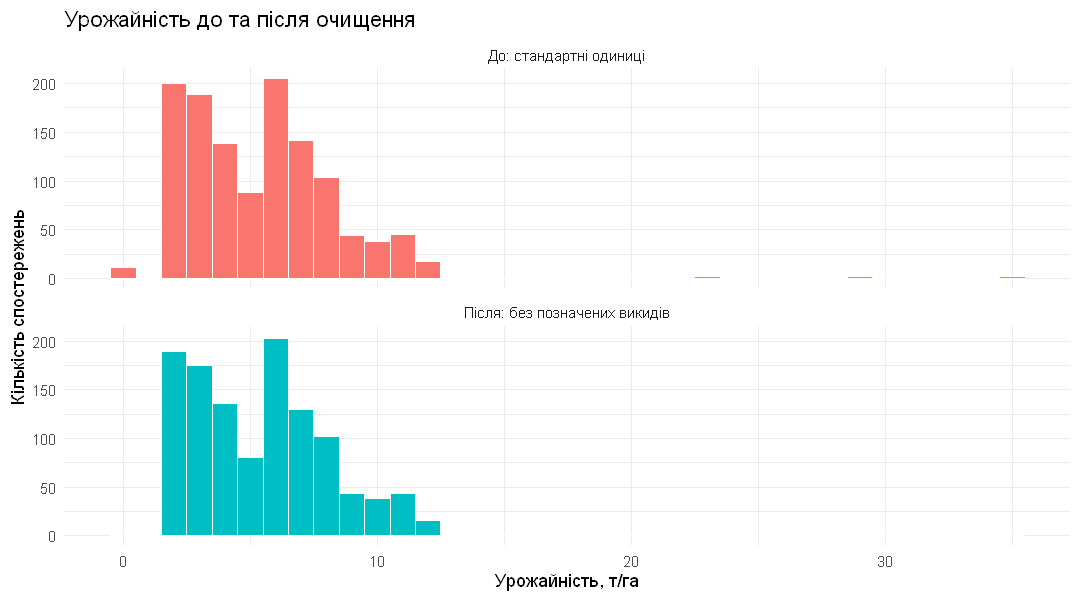

In [90]:
yield_plot <- bind_rows(
  data.frame(yield=raw_yt$yield_std,dataset="До: стандартні одиниці"),
  data.frame(yield=clean$yield_t_ha[clean$yield_outlier==0],dataset="Після: без позначених викидів")) |> filter(!is.na(yield))
p1 <- ggplot(yield_plot,aes(x=yield,fill=dataset)) + geom_histogram(binwidth=1,color="white") +
  facet_wrap(~dataset,ncol=1) + labs(title="Урожайність до та після очищення",x="Урожайність, т/га",y="Кількість спостережень",fill="Набір") +
  theme_minimal() + theme(legend.position="none")
print(p1)
ggsave(file.path(fig_dir, "p1_yield_distribution.png"), plot = p1, width = 8, height = 5, dpi = 300)

Вісь X показує урожайність у т/га, вісь Y — кількість супутникових спостережень у кожному інтервалі шириною 1 т/га. Верхня панель містить стандартну raw-урожайність, нижня — clean-підмножину без позначених викидів. У верхній панелі видно нефізичний лівий край і значення понад 18 т/га, які не входять до нижньої панелі. Зміна крайніх інтервалів пояснюється правилами аналітичного включення, а зміна кількостей — також дедуплікацією. Цей графік не доводить зміни реальної урожайності та не є польовим порівнянням із рівними вагами.

#### Що ми бачимо на графіку:
- **Верхня панель («До: стандартні одиниці»)**: Спостерігається двомодальність та великий розмах значень. Присутні нефізичні від'ємні значення (менше 0 т/га) та екстремальні викиди понад 18–35 т/га, спричинені первинною плутаниною одиниць виміру (`bu_ac` замість `t_ha`) або помилками некоректного введення.
- **Нижня панель («Після: без позначених викидів»)**: Розподіл стає згладженим і строго обмеженим допустимим діапазоном [0.5, 18] т/га. Основний пік урожайності зосереджений у районі 4.5–6.5 т/га, що відповідає типовим агрономічним нормативам. Усі негативні та екстремальні значення відсічені або позначені прапорцем `yield_outlier = 1`.

### 4.4 Розподіл NDVI

Порівнюємо щільності доступного NDVI до й після очищення. Однаковий безрозмірний масштаб дає змогу оцінити вплив корекції діапазону та дедуплікації.

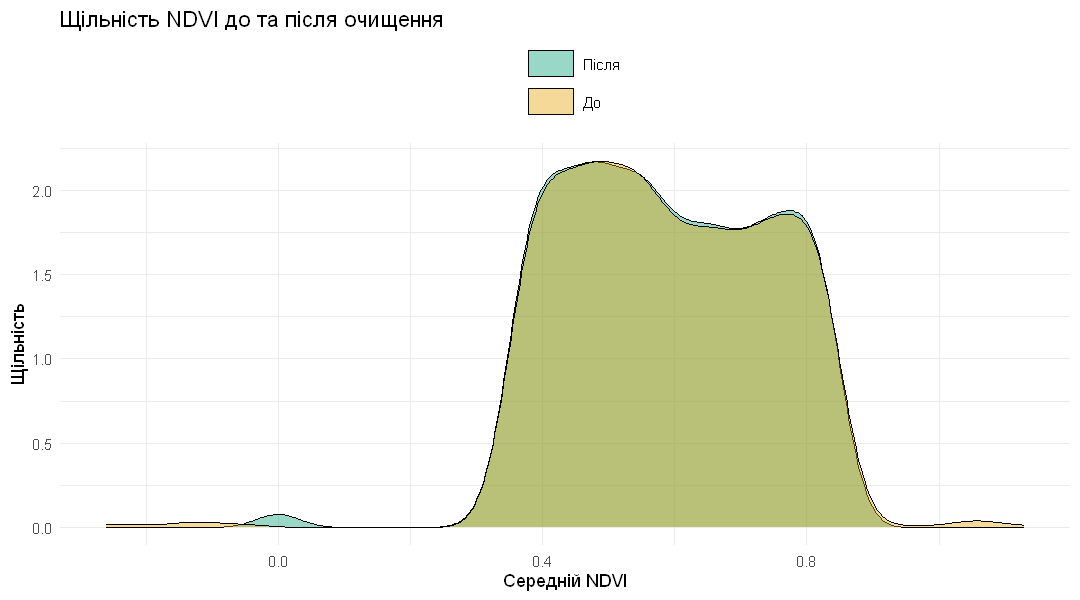

In [91]:
df_ndvi <- bind_rows(
  data.frame(ndvi=ndvi_raw[!is.na(ndvi_raw)], dataset="Сирий"),
  data.frame(ndvi=clean$ndvi_mean[!is.na(clean$ndvi_mean)], dataset="Очищений"))
p2 <- ggplot(df_ndvi, aes(x=ndvi, fill=dataset)) +
  geom_density(alpha=0.4) +
  scale_fill_manual(values=c("Сирий"="#E69F00", "Очищений"="#009E73"),labels=c("Очищений"="Після","Сирий"="До")) +
  guides(fill=guide_legend(ncol=1)) +
  labs(title="Щільність NDVI до та після очищення",
       x="Середній NDVI", y="Щільність", fill=NULL) +
  theme_minimal() + theme(legend.position="top",legend.key.width=grid::unit(1,"cm"),legend.spacing.x=grid::unit(.4,"cm"))
print(p2)
ggsave(file.path(fig_dir, "p2_ndvi_density.png"), plot = p2, width = 8, height = 5, dpi = 300)

Вісь X відображає середній NDVI, вісь Y — оцінену щільність його розподілу; помаранчевий колір позначає raw («До»), зелений — clean («Після»). Це нормовані розподіли доступних значень, а не кількість полів чи відсоток NA. В очищеному наборі зникають значення поза [0,1], а центральна частина розподілу змінюється помірно. Зменшення SD з 0.1601 до 0.1531 сумісне з корекцією крайніх значень, тоді як IQR змінюється з 0.2583 до 0.2568. Графік не доводить сезонної динаміки чи причинного зв’язку NDVI з урожайністю.

#### Що ми бачимо на графіку:
- **Порівняння щільностей («До» vs «Після»)**: Помаранчева крива («До / Сирий») має помітні «хвости» поза допустимим діапазоном [0, 1] — від'ємні значення (до -0.3, що вказують на суцільну хмарність/водні аномалії) та значення понад 1.0 (фізично неможливі для вегетаційного індексу).
- **Результат очищення (Зелена крива «Після / Очищений»)**: Крива повністю вміщена у межах фізично коректного інтервалу [0.0, 0.85] з піком щільності вегетації близько 0.58–0.65. Графік демонструє усунення артефактів спостереження та звуження стандартного відхилення (SD знизився з 0.1601 до 0.1531).

### 4.5 Агрегація фізичних полів і графік за культурами

Для стабільних категорій обираємо найчастіше відоме значення, а для площі, добрив і зрошення — медіану відомих стандартних значень. Урожайність поля — медіана валідних спостережень без викидів, NDVI — середнє доступних знімків. Кожне фізичне поле отримує один рядок і однакову вагу в польових KPI та графіку.

field_level: 180 полів; доступний yield: 160 ; soil NA: 0 ; irrigation NA: 0 


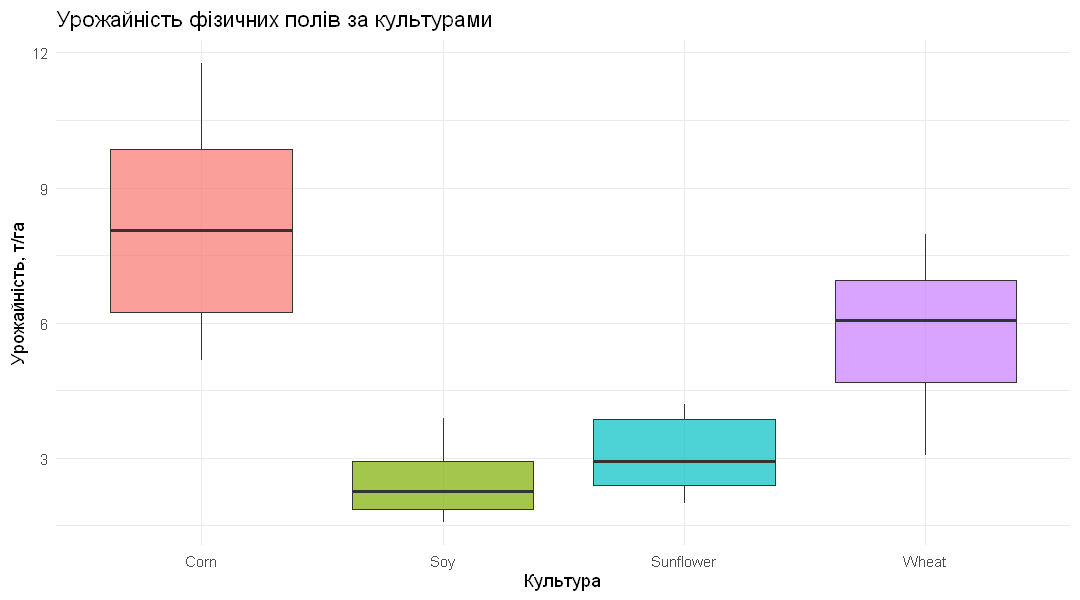

In [92]:
fy <- function(y, flag) {
  valid_median(y[!is.na(y) & flag == 0])
}

field_level <- clean |>
  group_by(base_field) |>
  summarise(
    farm_id = mode_known(farm_id),
    crop = mode_known(crop),
    soil_type = mode_known(soil_type),
    area = valid_median(area),
    fertilizer = valid_median(fertilizer_n_kg_ha),
    irrigation = valid_median(irrigation),
    ndvi_avg = if (all(is.na(ndvi_mean))) NA_real_ else mean(ndvi_mean, na.rm = TRUE),
    yield_t_ha = fy(yield_t_ha, yield_outlier),
    .groups = "drop"
  )

cat(
  "field_level:", nrow(field_level), "полів; доступний yield:", sum(!is.na(field_level$yield_t_ha)),
  "; soil NA:", sum(is.na(field_level$soil_type)), "; irrigation NA:", sum(is.na(field_level$irrigation)), "\n"
)

p3 <- ggplot(field_level |> filter(!is.na(yield_t_ha)), aes(x = crop, y = yield_t_ha, fill = crop)) +
  geom_boxplot(alpha = 0.7) +
  labs(
    title = "Урожайність фізичних полів за культурами",
    x = "Культура",
    y = "Урожайність, т/га"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

print(p3)
ggsave(file.path(fig_dir, "p3_crop_yield_boxplot.png"), plot = p3, width = 8, height = 5, dpi = 300)

Агрегована таблиця містить 180 фізичних полів, із яких 160 мають валідну урожайність; пропущених польових ґрунтів і зрошення немає завдяки іншим відомим спостереженням тих самих полів. На графіку X — культура, Y — польова урожайність у т/га; лінія в коробці є медіаною, коробка охоплює центральні 50% полів. Вищий розподіл кукурудзи відповідає заданому генератором діапазону, а соя та соняшник мають нижчі рівні. Кожне поле тут враховано один раз, тому кількість знімків не визначає його вагу. Відмінності культур є властивістю синтетичної моделі та не становлять порівняння ефективності господарювання.

#### Що ми бачимо на графіку:
- **Кукурудза (Corn)**: Позиціонується як найврожайніша культура з медіаною понад 8.0 т/га та міжквартильним розмахом (IQR) від ~6.5 до 10.0 т/га. Також демонструє найвищий 90-й процентиль (p90 = 10.79 т/га).
- **Пшениця (Wheat)**: Займає друге місце з медіаною ~6.06 т/га та стабільним помірним розмахом (більшість полів у межах 4.5–7.6 т/га).
- **Соняшник (Sunflower)**: Демонструє урожайність у межах 2.2–4.1 т/га з медіаною ~2.93 т/га.
- **Соя (Soy)**: Має найнижчу валову урожайність з медіаною ~2.25 т/га (IQR 1.8–3.5 т/га), що відповідає природним біологічним нормативам олійних і бобових культур.

---

## 5. Розрахунок десяти аналітичних KPI

Розрахунок ключових показників ефективності агрономічного набору даних.

Для польових KPI використовуємо 180 рядків field_level замість повторних супутникових знімків. Медіана валідної урожайності доступна для 160 полів, а 20 полів залишаються без цього показника. Відновлення стабільних атрибутів за іншими відомими спостереженнями поля не є міжпольовою імпутацією. Частку конвертованих записів та індикатор змін натомість рахуємо на рівні спостережень із явно вказаним знаменником.

### KPI 1: Поля та господарства

Рахуємо фізичні поля після дедуплікації за field_level. Кількість господарств визначаємо за їхніми унікальними відомими ідентифікаторами.

In [93]:
kpi1_fields <- nrow(field_level)
kpi1_farms  <- n_distinct(field_level$farm_id, na.rm=TRUE)
cat("KPI 1.  Унікальних полів:", kpi1_fields, "  Господарств:", kpi1_farms, "\n")

KPI 1.  Унікальних полів: 180   Господарств: 12 


Після зведення повторів залишилося 180 фізичних полів у 12 господарствах. Чотири додаткові raw-ідентифікатори не збільшують кількість фізичних об’єктів. Це база польових KPI, тоді як для аналізу урожайності доступно 160 із цих полів.

### KPI 2: Урожайність за культурами

Серед полів із валідною урожайністю обчислюємо кількість, середнє, медіану й 90-й перцентиль. p90 — значення, нижче якого лежить приблизно 90% польової вибірки, а не агрономічна межа норми.

In [94]:
kpi2 <- field_level |> filter(!is.na(yield_t_ha)) |>
  group_by(crop) |>
  summarise(n_полів=n(), mean=round(mean(yield_t_ha),3), median=round(median(yield_t_ha),3),
            p90=round(quantile(yield_t_ha,.9),3), .groups="drop") |>
  arrange(desc(median))
cat("KPI 2. Урожайність по культурах (t/ha, рівень полів):\n")
print(kpi2)

KPI 2. Урожайність по культурах (t/ha, рівень полів):
# A tibble: 4 × 5
  crop      n_полів  mean median    p90
  <chr>       <int> <dbl>  <dbl>  <dbl>
1 Corn           45 8.204  8.064 10.788
2 Wheat          62 5.724  6.059  7.628
3 Sunflower      19 3.107  2.93   4.125
4 Soy            34 2.453  2.254  3.546


Урожайність доступна для 45 полів Corn, 62 Wheat, 19 Sunflower і 34 Soy, разом 160 полів. Для Corn середнє, медіана й p90 дорівнюють 8.204, 8.064 та 10.788 т/га, для Wheat — 5.724, 6.059 та 7.628. Для Sunflower відповідні значення становлять 3.107, 2.930 та 4.125 т/га, для Soy — 2.453, 2.254 та 3.546. P90 описує верхню частину вибіркового розподілу й не є межею допустимості. Вищий рівень Corn відтворює задані культурі параметри генерації, а не доводить переваги культури за однакових умов.

### KPI 3: Частка конвертованої урожайності

Основний показник — частка yield_converted=1 серед усіх clean-спостережень. Додатковий розрахунок серед валідної урожайності використовує однакову підмножину в чисельнику й знаменнику.

In [95]:
kpi3_num <- sum(clean$yield_converted==1)
kpi3_den <- nrow(clean)
kpi3_pct <- round(100*kpi3_num/kpi3_den,2)
cat("KPI 3 — частка серед усіх clean-спостережень:",kpi3_num,"/",kpi3_den,"=",kpi3_pct,"%\n")
valid_y <- !is.na(clean$yield_t_ha)&clean$yield_outlier==0
cat("Додатково серед валідних: чисельник",sum(clean$yield_converted[valid_y]==1),
    "; знаменник",sum(valid_y),"; %",round(100*mean(clean$yield_converted[valid_y]==1),2),"\n")

KPI 3 — частка серед усіх clean-спостережень: 513 / 1443 = 35.55 %
Додатково серед валідних: чисельник 504 ; знаменник 1158 ; % 43.52 


Фактично конвертовано 513 із 1 443 clean-спостережень, що становить 35.55%. Основний знаменник містить усі очищені записи відповідно до змісту KPI 3. Додатково серед 1 158 валідних значень урожайності конвертовано 504, або 43.52%; чисельник тут також виключає викиди. Різниця часток виникає через різні аналітичні бази, а не через різні коефіцієнти конверсії.

### KPI 4: NDVI та урожайність

Кореляцію Пірсона обчислюємо між середнім NDVI поля та його медіанною валідною урожайністю. Використовуємо лише повні пари й показуємо кількість полів, щоб уникнути псевдоповторень супутникових знімків.

In [96]:
dk4 <- field_level |> filter(!is.na(ndvi_avg) & !is.na(yield_t_ha))
r_k4 <- round(cor(dk4$ndvi_avg, dk4$yield_t_ha, use = "complete.obs"), 3)
cat("KPI 4. Кореляція Пірсона між ndvi_mean та yield_t_ha (r):", r_k4, "\n")
cat("Пар фізичних полів:",nrow(dk4),"\n")

KPI 4. Кореляція Пірсона між ndvi_mean та yield_t_ha (r): -0.043 
Пар фізичних полів: 160 


Для 160 фізичних полів коефіцієнт Пірсона між середнім NDVI та урожайністю дорівнює −0.043. Від’ємний знак визначає напрям оціненого лінійного зв’язку, але мала абсолютна величина свідчить про практично відсутній лінійний зв’язок у цій синтетичній вибірці. Усереднення доступних знімків не враховує точні фази вегетації, тому показник має обмежену агрономічну інтерпретацію. Він не доводить причинності й не виключає нелінійних залежностей.

### KPI 5: Урожайність за ґрунтами

Для кожного відомого типу ґрунту показуємо кількість полів, медіану p50 та p75 урожайності. Це опис розподілів у синтетичній вибірці без контролю культур та інших чинників.

In [97]:
kpi5 <- field_level |>
  filter(!is.na(yield_t_ha) & !is.na(soil_type)) |>
  group_by(soil_type) |>
  summarise(
    n_fields = n(),
    median_p50 = round(median(yield_t_ha), 3),
    p75 = round(quantile(yield_t_ha, 0.75), 3),
    .groups = "drop"
  ) |>
  arrange(desc(median_p50))

cat("KPI 5. Урожайність за типами ґрунтів (p50 / median + p75):\n")
print(kpi5)


KPI 5. Урожайність за типами ґрунтів (p50 / median + p75):
# A tibble: 4 × 4
  soil_type n_fields median_p50   p75
  <chr>        <int>      <dbl> <dbl>
1 Sandy           24      5.845 7.09 
2 Loam            45      5.591 7.298
3 Chernozem       72      5.287 7.449
4 Clay            19      4.806 6.416


Група Sandy містить 24 поля з p50=5.845 і p75=7.090 т/га; Loam — 45 полів із 5.591 та 7.298. Для Chernozem 72 поля мають p50=5.287 і p75=7.449, для Clay 19 полів — 4.806 та 6.416 т/га. Медіана ділить групу навпіл, а p75 — значення, нижче якого лежить приблизно 75% польової вибірки групи. Відмінності можуть відображати різний склад культур та випадковість генерації. За цією таблицею не можна назвати певний ґрунт найкращим або встановити його причинний вплив.

### KPI 6: Азотні добрива та урожайність

Оцінюємо лінійний зв’язок між польовою дозою азоту й валідною урожайністю. Кореляція за повними парами описує сумісну зміну величин та не встановлює причинного впливу внесення добрив.

In [98]:
dk6 <- field_level |> filter(!is.na(fertilizer) & !is.na(yield_t_ha))
r_k6 <- round(cor(dk6$fertilizer, dk6$yield_t_ha, use = "complete.obs"), 3)
cat("KPI 6. Кореляція між внесеними добривами (kg/ha) та yield_t_ha (r):", r_k6, "\n")
cat("Пар фізичних полів:",nrow(dk6),"\n")

KPI 6. Кореляція між внесеними добривами (kg/ha) та yield_t_ha (r): -0.049 
Пар фізичних полів: 160 


Серед 160 повних польових пар кореляція дози азоту й урожайності дорівнює −0.049. Знак є від’ємним, проте абсолютне значення близьке до нуля й не показує помітної лінійної залежності. Добрива в генераторі не моделюють причинну зміну урожайності, тому слабкий зв’язок очікуваний для цієї моделі. Кореляція не є доказом користі або шкоди внесення азоту.

### KPI 7: Зрошення

Спершу визначаємо частку зрошуваних полів серед усіх полів із відомим зрошенням. Потім порівнюємо середню урожайність зрошуваних і незрошуваних полів лише там, де відомі обидва показники; різниця є описовою.

In [99]:
# Частина 1: частка зрошуваних полів серед усіх 180 фізичних полів з відомим irrigation
k7_all <- field_level |> filter(!is.na(irrigation))
n_all <- nrow(k7_all)
n_irr_all <- sum(k7_all$irrigation > 0)
n_noirr_all <- sum(k7_all$irrigation == 0)
pct_irr_all <- round(n_irr_all / n_all * 100, 1)

# Частина 2: порівняння урожайності серед 160 полів з відомим irrigation та yield
k7_y <- field_level |> filter(!is.na(irrigation) & !is.na(yield_t_ha))
n_irr_y <- sum(k7_y$irrigation > 0)
n_noirr_y <- sum(k7_y$irrigation == 0)
m_irr <- round(mean(k7_y$yield_t_ha[k7_y$irrigation > 0]), 3)
m_noirr <- round(mean(k7_y$yield_t_ha[k7_y$irrigation == 0]), 3)
diff_irr <- round(mean(k7_y$yield_t_ha[k7_y$irrigation>0])-mean(k7_y$yield_t_ha[k7_y$irrigation==0]),3)

cat("KPI 7. Частина 1 — частка зрошення (поля з відомим зрошенням):\n")
cat("Усього з відомим зрошенням: ", n_all, "\n")
cat("Зрошувані поля: ", n_irr_all, "(", pct_irr_all, "% )\n")
cat("Незрошувані поля: ", n_noirr_all, "(", round(100 - pct_irr_all, 1), "% )\n\n")

cat("Частина 2 — урожайність (поля з валідною урожайністю):\n")
cat("Зрошувані поля з yield: ", n_irr_y, "\n")
cat("Незрошувані поля з yield: ", n_noirr_y, "\n")
cat("Mean yield (зрошувані): ", m_irr, "t/ha\n")
cat("Mean yield (незрошувані): ", m_noirr, "t/ha\n")
cat("Різниця:", diff_irr, "t/ha\n")

KPI 7. Частина 1 — частка зрошення (поля з відомим зрошенням):
Усього з відомим зрошенням:  180 
Зрошувані поля:  110 ( 61.1 % )
Незрошувані поля:  70 ( 38.9 % )

Частина 2 — урожайність (поля з валідною урожайністю):
Зрошувані поля з yield:  93 
Незрошувані поля з yield:  67 
Mean yield (зрошувані):  5.309 t/ha
Mean yield (незрошувані):  5.563 t/ha
Різниця: -0.254 t/ha


Серед 180 полів із відомим зрошенням 110 є зрошуваними, тобто 61.1%, а 70 — незрошуваними, або 38.9%. Для порівняння урожайності доступні 93 зрошувані й 67 незрошуваних полів, разом 160. Середні становлять 5.309 та 5.563 т/га відповідно, а різниця зрошувані мінус незрошувані — −0.254 т/га. Це описова різниця синтетичних груп без контролю культур та інших чинників. Статистичний тест не проводився, тому результат не називаємо статистично значущим і не трактуємо як причинний ефект.

### KPI 8: Хмарність і пропуски супутникових спостережень NDVI

Визначаємо поля з повною відсутністю обох NDVI в наявних спостереженнях тижня 15–21 червня, враховуючи встановлені математично псевдоніми. Окремо показуємо хмарні NA, NA розсіяної хмарності поза суцільним блоком й короткі імпутації. Загальний вплив очищення на варіативність оцінюємо за SD та IQR; він включає також корекції й дедуплікацію.

In [100]:
cs <- as.Date("2024-06-15")
ce <- as.Date("2024-06-21")
cloud_records <- raw |> filter(as.Date(obs_date)>=cs & as.Date(obs_date)<=ce) |>
  mutate(base_field=field_id)
for (k in seq_len(nrow(alias_map))) {
  cloud_records$base_field[cloud_records$base_field == alias_map$removed[k]] <- alias_map$retained[k]
}
cloud_fields_observed <- cloud_records |> group_by(base_field) |>
  summarise(cloud=all(is.na(pn(ndvi_mean))) & all(is.na(pn(ndvi_max))),.groups="drop")
cg_fields_cnt <- sum(cloud_fields_observed$cloud)
cg_pct <- round(100*cg_fields_cnt/nrow(field_level),2)
imputed_cnt <- sum(clean$ndvi_imputed==1)
ndvi_na_cnt <- sum(is.na(clean$ndvi_mean))
ndvi_na_pct <- round(100 * ndvi_na_cnt / nrow(clean), 2)
sd_raw <- round(sd(ndvi_raw, na.rm = TRUE), 4)
sd_clean <- round(sd(clean$ndvi_mean, na.rm = TRUE), 4)
iqr_raw <- round(IQR(ndvi_raw, na.rm = TRUE), 4)
iqr_clean <- round(IQR(clean$ndvi_mean, na.rm = TRUE), 4)
cloud_clean <- clean$base_field %in% cloud_fields_observed$base_field[cloud_fields_observed$cloud] & clean$obs_date>=cs & clean$obs_date<=ce
scattered_remaining <- sum(is.na(clean$ndvi_mean)&!cloud_clean)
cat("KPI 8 — хмарні поля:",cg_fields_cnt,"/",nrow(field_level),"=",cg_pct,"%\n")
cat("Хмарні NA-спостереження:",sum(cloud_clean & is.na(clean$ndvi_mean)),"; NA поза суцільним хмарним блоком:",scattered_remaining,"\n")
cat("Короткі імпутації:",imputed_cnt,"; залишкові NA:",ndvi_na_cnt,"/",nrow(clean),"=",ndvi_na_pct,"%\n")
cat("SD до/після:",sd_raw,"/",sd_clean,"; IQR до/після:",iqr_raw,"/",iqr_clean,"\n")

KPI 8 — хмарні поля: 27 / 180 = 15 %
Хмарні NA-спостереження: 28 ; NA поза суцільним хмарним блоком: 187 
Короткі імпутації: 1 ; залишкові NA: 215 / 1443 = 14.9 %
SD до/після: 0.1601 / 0.1531 ; IQR до/після: 0.2583 / 0.2568 


Хмарна прогалина охоплює 27 із 180 фізичних полів, або 15%, і 28 залишкових NA-спостережень у тижні 15–21 червня. Інші 187 залишкових NA моделюють додаткові пропуски супутникових спостережень через розсіяну хмарність поза суцільним хмарним блоком. Відновлено одну коротку прогалину, а всього після очищення залишається 215 із 1 443 NA середнього NDVI, тобто 14.90%. SD змінюється з 0.1601 до 0.1531, IQR — з 0.2583 до 0.2568. Ці відмінності описують сумарний ефект корекцій, зведення повторів та однієї імпутації, а не ізольований вплив хмарності.

### KPI 9: П’ять господарств за медіаною

Ранжуємо господарства за медіаною валідної польової урожайності. field_count показує всі фізичні поля господарства, а yield_fields — поля з валідною урожайністю, що формують відповідну медіану.

In [101]:
kpi9 <- field_level |> filter(!is.na(farm_id)) |> group_by(farm_id) |>
  summarise(field_count=n(),yield_fields=sum(!is.na(yield_t_ha)),
    median_yield=valid_median(yield_t_ha),.groups="drop") |>
  filter(yield_fields>0) |> arrange(desc(median_yield),farm_id) |> mutate(median_yield=round(median_yield,2))
cat("KPI 9. Топ-5 господарств за медіаною; усі поля та валідна підмножина:\n")
print(head(kpi9,5))

KPI 9. Топ-5 господарств за медіаною; усі поля та валідна підмножина:
# A tibble: 5 × 4
  farm_id field_count yield_fields median_yield
  <chr>         <int>        <int>        <dbl>
1 FARM09           18           17         6.45
2 FARM06           11           11         6.32
3 FARM11           21           18         6.29
4 FARM12           14           11         6.22
5 FARM10           15           13         6.1 


П’ять господарств за медіаною валідної польової урожайності: FARM09 — 6.45 т/га, FARM06 — 6.32, FARM11 — 6.29, FARM12 — 6.22 і FARM10 — 6.10. Загалом ці господарства мають відповідно 18, 11, 21, 14 і 15 фізичних полів; валідна урожайність доступна відповідно для 17, 11, 18, 11 і 13. Медіани обчислено за валідною підмножиною, а всі поля показано окремим field_count, щоб явно описати розмір господарства. Ранжування виконано саме за медіаною, а не середнім. Відмінності не дозволяють зробити висновок про якість управління, оскільки дані синтетичні та склад культур у господарствах різний.

### KPI 10: Частка початкових рядків зі змінами

Для кожного raw_row_id об’єднуємо прапорці форматних виправлень, перерахунків, нормалізації, корекцій та вилучення дублікатів. Знаменник містить усі raw-рядки, включно з вилученими; сума кількостей операцій може перевищувати число унікальних змінених рядків.

In [102]:
rff <- rf |> mutate(is_removed=!raw_row_id %in% clean$raw_row_id)
operation_columns <- setdiff(names(rff),"raw_row_id")
rff$changed_any <- rowSums(rff[operation_columns])>0
kpi10_num <- sum(rff$changed_any)
kpi10_den <- nrow(raw)
kpi10 <- round(100*kpi10_num/kpi10_den,2)
operation_counts <- data.frame(Операція=operation_columns,Рядків=colSums(rff[operation_columns]))
cat("KPI 10:",kpi10_num,"/",kpi10_den,"=",kpi10,"%\n")
print(operation_counts,row.names=FALSE)

KPI 10: 1447 / 1506 = 96.08 %
          Операція Рядків
        num_parsed    292
  date_reformatted    182
      date_swapped     12
    unit_converted    919
   yield_converted    533
    cat_normalized    775
        ndvi_fixed     29
       coord_fixed     34
     invalid_to_na    424
 anomaly_corrected     34
   note_normalized     65
        is_removed     63


Щонайменше одне суттєве виправлення або вилучення має 1 447 із 1 506 raw-рядків, тобто 96.08%; 59 рядків не потребували жодної з обліковуваних операцій. За типами операцій відмічено 292 рядки парсингу, 182 переформатування дат, 12 перестановок дат, 919 інших конверсій одиниць і 533 конверсії урожайності. Нормалізація категорій охопила 775 рядків, корекція NDVI — 29, координат — 34, заміни некоректних або нестандартизованих значень на NA — 424. Позначення викидів і корекції вологості охопили 34 рядки, очищення приміток — 65, вилучення дублів — 63. Один raw-рядок може належати кільком групам, тому ці кількості не підсумовуємо як число унікальних змінених записів. Висока частка змін характеризує контрольовано зіпсований навчальний набір, а не реальну якість агрономічного обліку.

### 5.1 Три KPI до та після

Порівнюємо кількість ідентифікаторів полів, кореляцію NDVI з урожайністю та частку пропусків NDVI. До дедуплікації псевдоніми мають власну вагу; різниця кореляцій тому відображає і корекції NDVI, і зведення повторних полів.

In [103]:
# Три KPI до/після: різні field_id до зведення є ризиком подвійного врахування.
raw_fields <- raw |>
  mutate(
    yield_std = std_yield(raw),
    ndvi_num  = pn(ndvi_mean)
  ) |>
  group_by(field_id) |>
  summarise(
    yield = valid_median(yield_std[yield_std >= 0.5 & yield_std <= 18 & !is.na(yield_std)]),
    ndvi = if (all(is.na(ndvi_num))) NA_real_ else mean(ndvi_num, na.rm = TRUE),
    .groups = "drop"
  )

raw_r <- cor(raw_fields$yield, raw_fields$ndvi, use = "complete.obs")

kpi_comparison <- data.frame(
  Показник = c(
    "KPI 1: field_id / фізичні поля",
    "KPI 4: Pearson NDVI↔yield",
    "KPI 8: залишкові NDVI NA %"
  ),
  До = c(
    nrow(raw_fields),
    round(raw_r, 3),
    round(100 * mean(is.na(ndvi_raw)), 2)
  ),
  Після = c(
    nrow(field_level),
    r_k4,
    ndvi_na_pct
  )
)

kpi_comparison$Зміна <- round(kpi_comparison$Після - kpi_comparison$До, 3)
print(kpi_comparison, row.names = FALSE)

cat(
  "Поля з парою NDVI/yield до:", sum(complete.cases(raw_fields[c("yield", "ndvi")])),
  "; після:", nrow(dk4), "\n"
)

                       Показник      До   Після  Зміна
 KPI 1: field_id / фізичні поля 184.000 180.000 -4.000
      KPI 4: Pearson NDVI↔yield  -0.031  -0.043 -0.012
     KPI 8: залишкові NDVI NA %  15.270  14.900 -0.370
Поля з парою NDVI/yield до: 164 ; після: 160 


До зведення дублів є 184 field_id, після — 180 фізичних полів, тобто на чотири менше. Кореляція NDVI з валідною урожайністю змінюється з −0.031 на 164 парах до −0.043 на 160 парах; зміна −0.012 не змінює висновку про дуже слабкий лінійний зв’язок. Частка NA середнього NDVI зменшується з 15.27% до 14.90%, або на 0.37 відсоткового пункту. Ця зміна включає вилучення повторів і зміну знаменника, тому її не можна приписувати лише інтерполяції.

---

## 6. Підсумковий висновок

Узагальнюємо результати остаточного виконання всіх клітинок через Jupyter та IRkernel. Висновок стосується якості й описових властивостей цього синтетичного набору.

Синтетичний raw-набір містить 1 506 рядків і 28 колонок, які описують 180 фізичних полів 12 господарств у сезоні 2024. Основними проблемами є змішані одиниці, варіанти категорій, текстові числа, пропуски та дублікати; урожайність відсутня у 10.42%, NDVI — у 15.27% raw-рядків. У єдині одиниці переведено 447 площ, 373 значення зрошення, 377 значень опадів і 533 значення урожайності до дедуплікації. Вилучення 29 повних повторів і 34 спостережень чотирьох близьких псевдонімів залишило 1 443 clean-рядки та 41 колонку. Вісімнадцять виконуваних перевірок отримали 18 PASS і 0 WARN, включно з повторним точним пошуком близьких пар. Урожайність без відомих одиниць не вгадується й не імпутується: у clean залишилося 264 NA, або 18.30%, та 21 позначений викид, збережений для аудиту. Залежність пропусків від дощових тижнів означає, що аналіз лише доступної урожайності може нерівномірно представляти дати збирання. Хмарний тиждень охоплює 27 із 180 полів, відновлено лише одну коротку прогалину супутникових спостережень, а залишкові NA середнього NDVI становлять 215 із 1 443, або 14.90%. Польова агрегація дає валідну урожайність для 160 полів; медіани культур становлять 8.064 т/га для Corn, 6.059 для Wheat, 2.930 для Sunflower і 2.254 для Soy. Кореляції NDVI та азотних добрив з урожайністю дорівнюють −0.043 і −0.049 на 160 польових парах і не свідчать про помітний лінійний зв’язок. Зрошення відоме для всіх полів, 110 із 180 є зрошуваними, а описова різниця їхньої середньої урожайності з незрошуваними становить −0.254 т/га. Частка конвертованої урожайності дорівнює 513/1 443=35.55%, рейтинг господарств очолює FARM09 з медіаною 6.45 т/га, а KPI 10 становить 1 447/1 506=96.08% початкових рядків зі змінами. Очищення робить одиниці й групи порівнюваними та усуває повторну вагу записів, тому дані придатні для подальшої описової статистики й візуалізації з явними правилами виключення викидів. Синтетичний характер, невідомі одиниці, нерівномірні дати знімків і географічне обмеження центральною Україною залишаються підставами для обережної інтерпретації без причинних агрономічних висновків.